# B00 · Punto de partida del bloque B: diagnóstico de fallos con clasificadores

**Para quién.** Para ti, Jonathan. Es el cuaderno de arranque del bloque B y de tu objetivo específico 2 (OE2): extender a Rieth la comparativa de clasificadores de Prieto-Moreno et al. (2013) [VERIFICAR] —kNN, SVM, Random Forest y FCM— con validación por simulación, y cuantificar cuánto cambia el resultado frente a la validación aleatoria por muestra. A Cesar también le sirve: las reglas de medida y el formato de resultados son los mismos en los tres bloques.

**Qué vas a aprender.**
1. A montar el conjunto etiquetado del TEP clásico sin contaminar las clases, y a comprobar con los datos dónde entra el fallo.
2. A escalar sin fuga y entrenar tres clasificadores base: kNN, SVM y Random Forest.
3. A medir bien el diagnóstico (F1 por clase, macro-F1 y matriz de confusión), y por qué el «f1» del cuaderno 02 anterior no era un F1.
4. A reportar aparte los fallos 3, 9 y 15.
5. A hacer en miniatura el experimento de tu OE2 sobre Rieth (partición aleatoria por muestra frente a partición por simulación) y a reconocer una trampa propia de Rieth.
6. A guardar los resultados en el formato común y hacer un contraste pareado entre dos métodos.

**Prerrequisito.** Haber recorrido `01_primeros_pasos.ipynb` (detección con PCA, FAR, FDR y retardo). Este cuaderno sustituye como punto de partida al `02_arranque_diagnostico.ipynb`, que tiene dos defectos conocidos (B2 y B3 del informe de revisión del 27/09); aquí se esquivan y se explican.

**Qué necesitas.** El TEP clásico en `data/tep_classic/` (44 ficheros `.dat`) y, para las secciones 7 y 8, los Parquet de Rieth. La primera celda de código te dice dónde los busca. Si no están, esas partes se saltan con un mensaje y el resto corre igual.

**Cómo recorrerlo.** Primero *Run All*, para comprobar que todo corre en tu equipo. Después, celda por celda: lee la salida antes que el texto. Cada **Cómo leerlo** remite a la salida anterior, porque los resultados están ahí: en el texto no hay ninguno escrito a mano. Las celdas **Verifícalo tú** son mini ejercicios; intenta resolverlos antes de mirar la pista o la solución comentada. La sección **Te toca** es tu contribución y está sin resolver a propósito.

**Tiempo estimado.** La ejecución completa tiene como objetivo quedar por debajo de 10 minutos en un portátil sin GPU (la última celda imprime lo que tardó en el tuyo). La lectura con los ejercicios, una tarde.

> Escrito el 27 de septiembre de 2026 sobre la rama `revision-2026-09` (el paquete con los cambios del 22/09, aún sin la etiqueta `v0.3`). Los CSV que escribe van a `results/raw/`, que git ignora: son pruebas de humo del repositorio de Pablo, no resultados del bloque B. Los tuyos salen de tu repositorio. Revisado el mismo día contra las reglas de medida (`docs/reglas_de_medida.md`); el estado de los cuadernos de arranque está en `docs/estado_baselines_2026-09-27.md`.

## Las reglas de medida

Antes de tocar datos, las reglas del protocolo común. Son once y son las mismas en los tres bloques. Cada una existe porque evita una forma concreta de inflar (o de desinflar) los resultados. Aquí van en prosa breve, con la función del paquete que la implementa. Están fijadas en la sección 8 del traspaso v3, en `configs/baseline.yaml`, en `docs/decisiones.md` y en la revisión del 27/09 (`docs/revision_2026-09-27.md`).

1. **Partición por simulación, nunca por muestra** (`data.split_runs`). Las muestras consecutivas de una simulación se parecen mucho entre sí. Es la autocorrelación (*autocorrelation*): el proceso tiene inercia y se muestrea cada 3 minutos. Si esas muestras caen a los dos lados de la partición, el clasificador aprende a reconocer la simulación y no el fallo, y la cifra sale inflada. En el TEP clásico la regla se cumple sola, porque `dXX.dat` (entrenamiento) y `dXX_te.dat` (prueba) son simulaciones distintas. La sección 7 mide qué pasa si no se cumple. En Rieth hay un cuidado más: la simulación r de cada clase comparte semilla con la normal r (sección 7.2), así que se parte con los mismos ids en todas las clases y, en una validación cruzada, los grupos son `simulationRun`, nunca el par (fallo, simulación).
2. **Escalado ajustado solo con el entrenamiento** (`preprocessing.Scaler`: `fit` con el entrenamiento, `transform` con todo lo demás). Si la media y la desviación incluyen la prueba, el modelo ve información del examen antes de hacerlo. Es fuga de datos (*data leakage*).
3. **Umbrales calibrados con datos normales reservados.** En el paquete, `PCAMonitor.fit(X_fit, X_cal=...)` o `limits.limit_empirical` sobre datos que el modelo no vio; la fracción es `particion.calibracion_limites` del yaml, con corte temporal en el clásico y simulaciones normales distintas en Rieth. Un umbral calibrado con los datos del ajuste sale demasiado estrecho (cuaderno 01, sección 7), y uno que maximiza el F1 sobre la prueba es fuga. Los clasificadores de este cuaderno deciden por la clase más votada y no tienen umbral. En cuanto añadas uno (por ejemplo, rechazar una muestra si su pertenencia difusa máxima es baja), esta regla se aplica. Dos avisos de la verificación del 27/09 para cuando llegues ahí: `PCAMonitor.fit` sin `X_cal` calibra en muestra sin avisar, y el límite del SPE por Jackson sale de los autovalores de `X_fit`, así que en la práctica también es una calibración en muestra. Además, «no mirar la prueba» incluye no reutilizar para el resultado confirmatorio las simulaciones de Rieth que ya se han mirado en desarrollo (la lista está en `docs/reglas_de_medida.md`).
4. **Detección con `metrics.evaluate_run`.** La FAR se calcula sobre `stat[:onset]` y la FDR sobre `stat[onset:]`, con `onset = data.FAULT_ONSET_TEST` (160) en prueba. El retardo es la primera alarma de la primera racha de `k` alarmas seguidas (`protocolo.k_alarmas`). Si `detected_at_chance` es `True` (FDR < 0,10), el retardo no se interpreta, porque una racha de `k` puede salir por azar en 800 muestras autocorrelacionadas. **No uses `metrics.summary`** para el retardo medio ni para `fallos_nunca_detectados` (defecto I1): filtra a mano, como en la sección 8. Y lee siempre la FDR al lado de la FAR: `detected_at_chance` solo mira si la FDR es baja, así que un detector que alarma casi siempre pasa el filtro con FDR alta y retardo cero. En Rieth, la FAR se mide en las simulaciones normales de prueba, porque las 160 primeras muestras de cada fichero con fallo son copia de su gemela normal.
5. **Diagnóstico con F1 por clase sobre todo el conjunto de prueba, y macro-F1.** Hoy se calcula con `sklearn.metrics`, porque el paquete aún no tiene función propia. La precisión de una clase necesita los falsos positivos que llegan *desde las otras clases*. Si calculas el F1 solo con las muestras de esa clase, la precisión vale 1 y el «F1» se queda en 2r/(1+r) (defecto B3). La sección 5 lo demuestra.
6. **Dónde entra el fallo: `data.fault_onset(split, fuente)`.** En los `dXX.dat` del clásico el fallo está activo desde la fila 0, así que se usan las 480 filas enteras; `fault_onset("train", "classic")` devuelve `None`. **No uses `data.FAULT_ONSET_TRAIN_CLASSIC`**: vale 20 y es un dato falso (defecto B2). La sección 2 lo comprueba. En Rieth el fallo entra tras la muestra 20 en entrenamiento (`FAULT_ONSET_TRAIN_RIETH`) y tras la 160 en prueba. Además, el inicio nominal no siempre es el efectivo: en algunos fallos de Rieth la trayectoria sigue idéntica a su gemela normal unas cuantas muestras después del inicio, así que al descartar solo `sample <= onset` quedan algunas filas con etiqueta de fallo que son copia exacta de la clase 0. Es ruido de etiqueta menor: se mide (sección 7.2) y se declara, no se corrige a ojo. Etiquetar como fallo muestras sanas, o al revés, contamina las clases.
7. **Los fallos 3, 9 y 15 se reportan siempre aparte** (`metrics.HARD_FAULTS`). Promediarlos con el resto esconde el único sitio donde los métodos se diferencian, que es además donde la fuga más infla.
8. **Contrastes: Wilcoxon pareado con corrección de Holm por fallo** (`stats.compare_methods`, con `zero_method="zsplit"`), y α = 0,05 declarado antes de ver resultados. Se reporta la diferencia, no solo el p: con muchas simulaciones casi todo sale significativo. Hoy `compare_methods` hace todos contra todos; el análisis principal contra el baseline llega en v0.3. Con una sola simulación (TEP clásico) no hay contraste posible, y esos números son orientativos.
9. **Semillas y configuración salen de `configs/baseline.yaml`** (`protocolo.semilla`, `particion.*`, `datos.runs_desarrollo`, `protocolo.k_alarmas`…). Nada que esté en el yaml se fija a mano en una celda. Ojo con los nombres: `protocolo.alpha` es el nivel de confianza del límite de control, no el α de los contrastes.
10. **Ningún número de resultado se escribe a mano en el texto.** Las interpretaciones remiten a la salida de la celda. Un número copiado a mano se desactualiza en cuanto cambia algo, y en este proyecto ya pasó con las cifras de calibración de septiembre.
11. **Formato común de resultados: una fila por (`method`, `faultNumber`, `simulationRun`).** En detección, las columnas de `evaluate_run`. En diagnóstico, el recall por (fallo, simulación), y la precisión y el F1 por clase calculados sobre el conjunto (*pool*) de prueba. Mientras sea prueba de humo, va a `results/raw/` (git lo ignora) y no a `results/summary/`. Es el formato que consumen `metrics.aggregate` y `stats.compare_methods` en los tres bloques.

In [1]:
# Primera celda: directorio de trabajo, configuración común y dónde están los datos de Rieth.
import os
import time
from pathlib import Path

import yaml

T0 = time.perf_counter()                      # para medir lo que tarda el cuaderno entero

# Los cuadernos viven en notebooks/ y los datos en data/: se sube un nivel si hace falta.
if not Path("data").exists() and Path("../data").exists():
    os.chdir("..")
print("Directorio de trabajo:", os.getcwd())

# Regla 9: lo que está en el yaml se lee del yaml.
with open("configs/baseline.yaml", encoding="utf-8") as fh:
    CFG = yaml.safe_load(fh)

SEMILLA      = CFG["protocolo"]["semilla"]
K_ALARMAS    = CFG["protocolo"]["k_alarmas"]
MINUTOS      = CFG["protocolo"]["sample_minutes"]
FRACCIONES   = (CFG["particion"]["fraccion_ajuste"],
                CFG["particion"]["fraccion_validacion"],
                CFG["particion"]["fraccion_prueba"])
RUNS_DEV     = CFG["datos"]["runs_desarrollo"]    # simulaciones por clase durante el desarrollo
RUNS_FINALES = CFG["datos"]["runs_finales"]

# Regla 8: el alfa de los contrastes se declara aquí, antes de ver ningún resultado.
# Aún no está en el yaml (defecto I2); no confundirlo con protocolo.alpha (nivel del límite).
ALPHA_CONTRASTES = 0.05

print(f"semilla={SEMILLA} | k_alarmas={K_ALARMAS} | fracciones={FRACCIONES} | "
      f"runs_desarrollo={RUNS_DEV} | runs_finales={RUNS_FINALES} | alfa contrastes={ALPHA_CONTRASTES}")

# Carpeta de los Parquet de Rieth, por este orden de prioridad:
#   1) la variable de entorno TFM_RIETH_DIR;  2) data/tep_rieth, si tiene *.parquet;
#   3) ~/datos_tfm/tep_rieth, fuera de OneDrive y Google Drive.
def _tiene_parquet(carpeta):
    return carpeta.is_dir() and any(carpeta.glob("*.parquet"))

if os.environ.get("TFM_RIETH_DIR"):
    RIETH_DIR, _origen = Path(os.environ["TFM_RIETH_DIR"]), "variable de entorno TFM_RIETH_DIR"
elif _tiene_parquet(Path("data/tep_rieth")):
    RIETH_DIR, _origen = Path("data/tep_rieth"), "data/tep_rieth, dentro del repositorio"
else:
    RIETH_DIR, _origen = Path.home() / "datos_tfm" / "tep_rieth", "carpeta por defecto ~/datos_tfm/tep_rieth"

FICHEROS_RIETH = [f"{s}_fault{k:02d}.parquet" for s in ("train", "test") for k in range(21)]
_faltan = [f for f in FICHEROS_RIETH if not (RIETH_DIR / f).exists()]
HAY_RIETH = not _faltan
print(f"Rieth: uso {RIETH_DIR} ({_origen})")
if HAY_RIETH:
    print(f"  están los {len(FICHEROS_RIETH)} Parquet: se ejecutan las partes de Rieth (secciones 7 y 8)")
else:
    print(f"  faltan {len(_faltan)} de {len(FICHEROS_RIETH)} Parquet: las partes de Rieth se saltarán")

SIN_RIETH = f"""Parte de Rieth saltada: no encuentro los {len(FICHEROS_RIETH)} Parquet en {RIETH_DIR}.
Lo recomendado: pídele a Pablo los Parquet y su manifiesto SHA-256, cópialos fuera de OneDrive
o Google Drive (por ejemplo, en ~/datos_tfm/tep_rieth), comprueba el hash con 'sha256sum -c' y,
si usas otra carpeta, define la variable de entorno TFM_RIETH_DIR antes de abrir Jupyter.
Si tienes que convertirlos tú, hazlo de uno en uno y de menor a mayor, con el navegador cerrado
y preferiblemente fuera de OneDrive o Google Drive:
  python -m tfmfdd.convert_rieth --origen <carpeta .RData> --destino ~/datos_tfm/tep_rieth --solo <fichero>
con <fichero> = faultfree_training, faultfree_testing, faulty_training y, al final,
faulty_testing, que es el que más memoria pide."""

Directorio de trabajo: C:\Users\pabdu\OneDrive\Documentos\Universidades\UNIR\TFM\tfm-fdd-core\tfm-fdd-core
semilla=42 | k_alarmas=3 | fracciones=(0.6, 0.2, 0.2) | runs_desarrollo=20 | runs_finales=100 | alfa contrastes=0.05
Rieth: uso C:\Users\pabdu\datos_tfm\tep_rieth (carpeta por defecto ~/datos_tfm/tep_rieth)
  están los 42 Parquet: se ejecutan las partes de Rieth (secciones 7 y 8)


In [2]:
# Imports. Lo que viene del paquete lleva el prefijo tfmfdd; lo demás es numpy, pandas y scikit-learn.
import gc
import inspect
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, f1_score, precision_recall_fscore_support,
                             recall_score)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import tfmfdd
from tfmfdd import data, metrics, plots, stats
from tfmfdd.preprocessing import Scaler

plots.use_style()                               # plots.py: el estilo común de las figuras
pd.set_option("display.width", 160)
assert CFG["datos"]["fault_onset_test"] == data.FAULT_ONSET_TEST   # el yaml y el paquete coinciden

# Versiones (I7 de la revisión): un resultado sin versiones no se puede reproducir.
print("Python", sys.version.split()[0], "| numpy", np.__version__, "| pandas", pd.__version__,
      "| scikit-learn", sklearn.__version__, "| tfmfdd", tfmfdd.__version__)

Python 3.12.0 | numpy 2.5.3 | pandas 3.0.6 | scikit-learn 1.9.1 | tfmfdd 0.1.0


## 1. Detectar frente a diagnosticar

En el 01 viste cómo **detectar**: responder *sí o no* (¿hay fallo?) con un modelo que solo conoce la operación normal (PCA, T² y SPE). Eso se mide con FAR, FDR y retardo.

**Diagnosticar** es responder *cuál*: de los fallos conocidos, ¿cuál es este? Es clasificación supervisada, y necesita ejemplos etiquetados de cada fallo. En planta, detectar es que salte la alarma en el panel; diagnosticar es que el operador sepa si tiene que revisar la válvula del condensador o el suministro de la alimentación A. Se mide con el F1 por clase, el macro-F1 y la matriz de confusión (*confusion matrix*), que son las métricas de la sección 5.

Las dos tareas se tocan: un clasificador también detecta, porque cualquier predicción distinta de «normal» es una alarma. La sección 8 lo mide así, con `metrics.evaluate_run`, para que tus clasificadores se puedan comparar con el PCA de Pablo usando las mismas métricas.

## 2. El conjunto etiquetado del TEP clásico → `data.py`

`data.load_classic(fallo, split)` devuelve un DataFrame con el contrato común: `faultNumber`, `simulationRun`, `sample` y las 52 variables. La columna `faultNumber` es directamente la etiqueta.

Hay dos tipos de fichero, y conviene no mezclarlos:

- **Entrenamiento** (`dXX.dat`, `split="train"`). `d00.dat` tiene 500 muestras de operación normal y viene transpuesto: el paquete lo corrige y avisa, por eso verás un aviso en rojo. Los ficheros `d01.dat` a `d21.dat` tienen **480 muestras con el fallo activo desde la primera fila**, así que se usan enteros. `data.fault_onset("train", "classic")` devuelve `None`, que significa justo eso.
- **Prueba** (`dXX_te.dat`, `split="test"`). Tienen 960 muestras y el fallo entra tras la muestra 160 (`data.fault_onset("test")`). Para el diagnóstico se toman las 800 posteriores de cada fichero de fallo y las 960 de `d00_te.dat`.

Son 22 clases: la 0 (normal) y los fallos 1 a 21.

In [3]:
ONSET_TR_CL = data.fault_onset("train", "classic")   # None: el fallo está activo desde la fila 0
ONSET_TE    = data.fault_onset("test")               # 160
CLASES_CL   = list(range(22))                        # 0 = normal, 1..21 = fallos

X_tr, y_tr, X_te, y_te = [], [], [], []
for f in CLASES_CL:
    tr = data.load_classic(f, "train")               # dXX.dat: se usa entero (regla 6)
    te = data.load_classic(f, "test")                # dXX_te.dat
    if f > 0:
        te = te[te["sample"] > ONSET_TE]             # solo las muestras con el fallo ya activo
    X_tr.append(data.values(tr)); y_tr.append(tr["faultNumber"].to_numpy())
    X_te.append(data.values(te)); y_te.append(te["faultNumber"].to_numpy())

X_tr, y_tr = np.vstack(X_tr), np.concatenate(y_tr)
X_te, y_te = np.vstack(X_te), np.concatenate(y_te)
print("Onset de entrenamiento (clásico):", ONSET_TR_CL, "| onset de prueba:", ONSET_TE)
print("Entrenamiento:", X_tr.shape, "| prueba:", X_te.shape)
print("Muestras por clase en entrenamiento:", np.bincount(y_tr).tolist())
print("Muestras por clase en prueba       :", np.bincount(y_te).tolist())

C:\Users\pabdu\OneDrive\Documentos\Universidades\UNIR\TFM\tfm-fdd-core\tfm-fdd-core\tfmfdd\data.py:132: UserWarning: d00.dat: matriz transpuesta (52, 500), se corrige a (500, 52). Es el caso conocido de d00.dat.
  arr = _as_samples_by_vars(np.loadtxt(path), path.name)


Onset de entrenamiento (clásico): None | onset de prueba: 160
Entrenamiento: (10580, 52) | prueba: (17760, 52)
Muestras por clase en entrenamiento: [500, 480, 480, 480, 480, 480, 480, 480, 480, 480, 480, 480, 480, 480, 480, 480, 480, 480, 480, 480, 480, 480]
Muestras por clase en prueba       : [960, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800]


### Verifícalo tú: ¿desde qué fila está activo el fallo?

La versión anterior del cuaderno 02 descartaba las 20 primeras filas de cada `dXX.dat` porque `data.FAULT_ONSET_TRAIN_CLASSIC` vale 20. Ese dato es falso (defecto B2 de la revisión), y lo puedes comprobar con un fallo que deja una huella inconfundible: el IDV 6, la pérdida de la alimentación A. Con ese fallo activo, `xmeas_1` (el caudal de la alimentación A) cae prácticamente a cero.

La celda compara `xmeas_1` en tres ficheros: `d00.dat` (normal), `d06.dat` (entrenamiento con el fallo 6) y `d06_te.dat` (prueba con el fallo 6).

xmeas_1 medio en d00.dat (normal)       : 0.2511
xmeas_1 en d06.dat, filas 0-4           : [ 0.0004  0.0021 -0.0001  0.001   0.0004]
xmeas_1 medio en d06.dat, filas 0-19    : -0.0001
xmeas_1 medio en d06.dat, filas 20-479  : -0.0001
Primer índice caído en d06_te.dat       : 160  (onset de prueba = 160)
¿Algún índice caído antes del onset?    : False


C:\Users\pabdu\OneDrive\Documentos\Universidades\UNIR\TFM\tfm-fdd-core\tfm-fdd-core\tfmfdd\data.py:132: UserWarning: d00.dat: matriz transpuesta (52, 500), se corrige a (500, 52). Es el caso conocido de d00.dat.
  arr = _as_samples_by_vars(np.loadtxt(path), path.name)


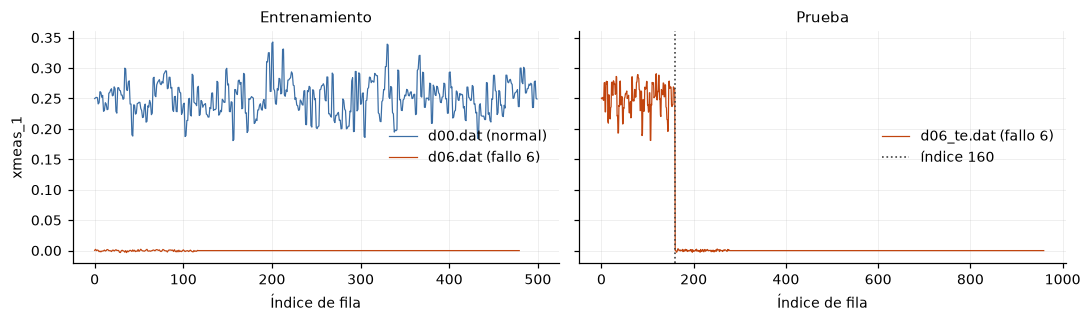

In [4]:
x_normal = data.load_classic(0, "train")["xmeas_1"].to_numpy()   # d00.dat
x_tr6    = data.load_classic(6, "train")["xmeas_1"].to_numpy()   # d06.dat
x_te6    = data.load_classic(6, "test")["xmeas_1"].to_numpy()    # d06_te.dat

media_normal = x_normal.mean()
caido = x_te6 < media_normal / 2              # "caído": por debajo de la mitad de lo normal
print(f"xmeas_1 medio en d00.dat (normal)       : {media_normal:.4f}")
print(f"xmeas_1 en d06.dat, filas 0-4           : {np.round(x_tr6[:5], 4)}")
print(f"xmeas_1 medio en d06.dat, filas 0-19    : {x_tr6[:20].mean():.4f}")
print(f"xmeas_1 medio en d06.dat, filas 20-479  : {x_tr6[20:].mean():.4f}")
print(f"Primer índice caído en d06_te.dat       : {int(np.argmax(caido))}  (onset de prueba = {ONSET_TE})")
print(f"¿Algún índice caído antes del onset?    : {bool(caido[:ONSET_TE].any())}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
axes[0].plot(x_normal, color=plots.COLORS["normal"], lw=0.8, label="d00.dat (normal)")
axes[0].plot(x_tr6, color=plots.COLORS["fault"], lw=0.8, label="d06.dat (fallo 6)")
axes[0].set_title("Entrenamiento"); axes[0].set_xlabel("Índice de fila"); axes[0].set_ylabel("xmeas_1")
axes[0].legend(loc="center right")
axes[1].plot(x_te6, color=plots.COLORS["fault"], lw=0.8, label="d06_te.dat (fallo 6)")
axes[1].axvline(ONSET_TE, color=plots.COLORS["limit"], ls=":", label="índice 160")
axes[1].set_title("Prueba"); axes[1].set_xlabel("Índice de fila"); axes[1].legend(loc="center right")
plt.tight_layout()

**Cómo leerlo.** Fíjate en las primeras líneas de la salida: en `d06.dat` el caudal de A ya está en el suelo en la fila 0, muy lejos de la media normal, y la media de las filas 0–19 es igual de baja que la del resto del fichero. No hay ninguna «hora sana» al principio. En el fichero de prueba, en cambio, la caída llega justo en el índice 160, y ni un índice antes. Conclusión: en el clásico, las 480 filas de cada `dXX.dat` son de fallo y se usan enteras. Descartar 20 tiraba muestras con fallo, y la docstring que sugería «reetiquetarlas» habría metido muestras defectuosas en la clase normal. Por eso este cuaderno usa `data.fault_onset("train", "classic")` y nunca `FAULT_ONSET_TRAIN_CLASSIC`.

¿De dónde salió el 20? Es de Rieth: allí el fallo entra tras la muestra 20 en los ficheros de entrenamiento (sección 7). La tabla de `data/tep_classic/LEEME_TEP_clasico.md` se lo atribuye bien a Rieth; en algún momento se mezclaron los dos conjuntos.

**Ejercicio.** Con el fallo 1 la historia parece otra: las primeras filas de `d01.dat` se ven normales, y alguien podría concluir que sí hay una hora sana. Antes de mirar la solución, piensa cómo distinguirías «el fallo entra en la fila 20» de «el fallo entra en la fila 0, pero el proceso tarda en responder». Pista: en `d01_te.dat` sabes exactamente cuándo entra el fallo.

In [5]:
# Verifícalo tú (solución comentada; descoméntala después de intentarlo).
# x_tr1 = data.load_classic(1, "train")["xmeas_1"].to_numpy()          # d01.dat
# x_te1 = data.load_classic(1, "test")["xmeas_1"].to_numpy()           # d01_te.dat
# limite = x_normal.mean() + 3 * x_normal.std(ddof=1)                  # fuera de lo normal
# print("d01.dat   : primera fila fuera de lo normal:", int(np.argmax(x_tr1 > limite)))
# print("d01_te.dat: primera fila fuera de lo normal, contada desde el onset:",
#       int(np.argmax(x_te1[ONSET_TE:] > limite)))
# Si el retraso es el mismo en los dos ficheros, el fallo entró en la fila 0 de d01.dat: lo que
# parece una hora sana es la dinámica del proceso, que tarda unas muestras en responder.

## 3. Escalar solo con el entrenamiento → `preprocessing.py`

Las 52 variables tienen unidades distintas: caudales, presiones, temperaturas y posiciones de válvula. Sin escalar, la distancia del kNN y el margen de la SVM los dominaría la variable con los números más grandes. `Scaler` resta la media y divide por la desviación **aprendidas solo con el entrenamiento** (regla 2), y aplica esas mismas al resto.

Una decisión que conviene dejar escrita: aquí la media y la desviación salen de todo el entrenamiento (las 22 clases), como en el 02. Otra opción defendible es usar solo la clase normal, como hace el PCA del bloque A. Las dos están libres de fuga; lo que no vale es pasar de una a otra sin anotarlo en `decisiones.md`.

In [6]:
escalador = Scaler().fit(X_tr)          # regla 2: fit SOLO con el entrenamiento
Z_tr = escalador.transform(X_tr)
Z_te = escalador.transform(X_te)        # la prueba se transforma con la media y la desviación del entrenamiento
print("Máx. |media| por variable en Z_tr:", np.abs(Z_tr.mean(axis=0)).max().round(6))
print("Máx. |media| por variable en Z_te:", np.abs(Z_te.mean(axis=0)).max().round(3))

Máx. |media| por variable en Z_tr: 0.0
Máx. |media| por variable en Z_te: 0.496


**Cómo leerlo.** En entrenamiento, las medias son cero por construcción. En prueba no lo son, y está bien que no lo sean: la prueba es otra simulación, con otra mezcla de muestras (800 por fallo frente a 480), así que sus medias no tienen por qué coincidir. Si forzaras media cero también en la prueba escalando con ella, usarías datos del examen para preparar el modelo.

### Verifícalo tú: ¿cuánto cambia la cifra si el escalador ve la prueba?

Ajusta `Scaler` con el entrenamiento y la prueba juntos, entrena un kNN y compara su macro-F1 con el de la sección 4. Es la fuga de la regla 2 hecha a propósito, así que la solución queda comentada.

In [7]:
# Verifícalo tú (solución comentada). Ejecútala DESPUÉS de la sección 4, para tener con qué comparar.
# esc_fuga = Scaler().fit(np.vstack([X_tr, X_te]))          # <- fuga: el escalador ve la prueba
# knn_fuga = KNeighborsClassifier(n_neighbors=5).fit(esc_fuga.transform(X_tr), y_tr)
# y_fuga = knn_fuga.predict(esc_fuga.transform(X_te))
# print("macro-F1 del kNN con escalado con fuga:", round(f1_score(y_te, y_fuga, average="macro"), 3))
# Pregunta: ¿sube, baja o no se mueve? Esta fuga puede mover la cifra en cualquier sentido; lo que
# la hace inaceptable no es el signo, sino que la cifra deja de medir lo que dice medir.

## 4. Tres clasificadores base → scikit-learn

Son tres clasificadores clásicos, los de la comparativa de Prieto-Moreno et al. (2013) [VERIFICAR] salvo el FCM, que es tuyo (sección 9):

- **kNN** (*k-nearest neighbors*, k vecinos más cercanos): etiqueta una muestra con la clase mayoritaria entre sus k vecinos más cercanos del entrenamiento. No aprende nada, memoriza. Por eso es el más expuesto a la fuga por autocorrelación.
- **SVM** (*support vector machine*, máquina de vectores de soporte) con núcleo RBF: busca fronteras de margen máximo en un espacio transformado. Con 22 clases entrena un clasificador por cada par de clases.
- **Random Forest** (bosque aleatorio): muchos árboles de decisión, entrenados sobre remuestreos y subconjuntos de variables, que votan.

**Sin ajustar hiperparámetros, a propósito.** Se usan los valores por defecto de scikit-learn, escritos explícitamente para que un cambio de versión no los mueva. Hay tres razones:
1. Son el suelo contra el que se mide todo lo demás. Si el FCM, con toda su maquinaria, no mejora a un Random Forest de serie, hay que decirlo.
2. Ajustar exige una partición de validación por simulación. En el clásico hay una sola simulación por clase, así que no existe una validación honesta, y ajustar mirando la prueba sería fuga (regla 3).
3. Ajustar con una validación aleatoria por muestra optimizaría una cifra contaminada: los hiperparámetros ganadores serían los que mejor puntúan en un examen con fuga, y nada garantiza que sean los mejores para una simulación nueva. En Rieth sí se puede hacer bien, con simulaciones de validación reservadas; es parte del **Te toca**.

Las semillas salen de `protocolo.semilla`. En el clásico, la SVM entrena con todo el conjunto porque es pequeño. Con cientos de simulaciones de Rieth no escalaría (su coste de entrenamiento crece entre cuadrática y cúbicamente con el número de muestras), y allí habrá que submuestrear de forma estratificada por clase y simulación.

In [8]:
# Fábricas: cada llamada devuelve un clasificador nuevo, sin entrenar.
# Son los valores por defecto de scikit-learn, escritos a mano para que no dependan de la versión.
FABRICAS = {
    "kNN": lambda: KNeighborsClassifier(n_neighbors=5),
    "SVM": lambda: SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEMILLA),
    "RF":  lambda: RandomForestClassifier(n_estimators=100, random_state=SEMILLA, n_jobs=-1),
}

pred_cl = {}                                    # predicciones sobre la prueba del clásico
for nombre, fabrica in FABRICAS.items():
    t = time.perf_counter()
    modelo = fabrica().fit(Z_tr, y_tr)
    pred_cl[nombre] = modelo.predict(Z_te)
    print(f"{nombre:4s} macro-F1 = {f1_score(y_te, pred_cl[nombre], average='macro'):.3f}"
          f"   ({time.perf_counter() - t:.1f} s entre entrenar y predecir)")
    del modelo

kNN  macro-F1 = 0.392   (0.2 s entre entrenar y predecir)


SVM  macro-F1 = 0.506   (39.1 s entre entrenar y predecir)


RF   macro-F1 = 0.631   (5.2 s entre entrenar y predecir)


**Cómo leerlo.** Fíjate primero en el orden de los tres y en la distancia entre ellos, no en cada cifra suelta: es una sola simulación por clase, así que los valores absolutos son orientativos (regla 8). Una hipótesis que puedes comprobar sobre por qué el kNN queda atrás: la distancia euclídea pesa igual las 52 variables, y para distinguir un fallo concreto importan unas pocas; las demás meten ruido en la distancia. El Random Forest, en cambio, elige en cada corte la variable que más separa. El macro-F1 promedia las 22 clases con el mismo peso; la sección 5 abre ese promedio.

## 5. Medir bien → `sklearn.metrics`

### 5.1 F1 por clase y macro-F1

Para cada clase c, y sobre **todo** el conjunto de prueba:
- La **precisión** (*precision*): de las muestras que el clasificador llamó c, qué fracción era c de verdad. Aquí entran los falsos positivos que vienen de otras clases.
- El **recall** (sensibilidad o exhaustividad): de las muestras que eran c, qué fracción llamó c. Es la FDR del diagnóstico.
- El **F1**: la media armónica de las dos, 2pr/(p+r). Solo es alta si las dos lo son.

El **macro-F1** es la media simple de los F1 de las clases. Cada clase pesa lo mismo, así que las difíciles no se esconden detrás de las fáciles.

macro-F1 (media de cada columna): {'kNN': 0.392, 'SVM': 0.506, 'RF': 0.631}


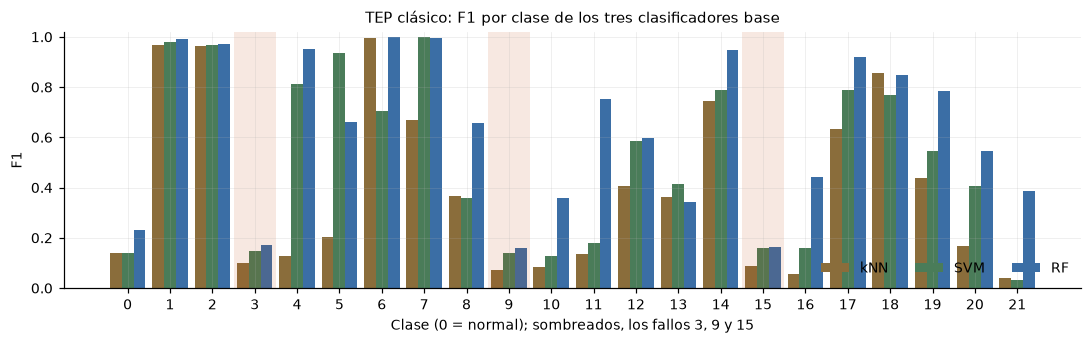

In [9]:
def tabla_por_clase(y_true, y_pred, clases, metodo, **extra):
    """Precisión, recall y F1 de cada clase, calculados sobre TODO el conjunto de prueba (regla 5)."""
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred, labels=clases, zero_division=0)
    return pd.DataFrame({"method": metodo, "faultNumber": clases, **extra,
                         "precision": p, "recall": r, "f1": f, "support": s})

por_clase_cl = pd.concat([tabla_por_clase(y_te, pred_cl[m], CLASES_CL, m) for m in FABRICAS],
                         ignore_index=True)
f1_cl = por_clase_cl.pivot(index="faultNumber", columns="method", values="f1")[list(FABRICAS)]
print("macro-F1 (media de cada columna):", f1_cl.mean().round(3).to_dict())

fig, ax = plt.subplots(figsize=(10, 3.2))
ancho = 0.28
for i, (m, color) in enumerate(zip(FABRICAS, ["alt2", "alt1", "normal"])):
    ax.bar(np.array(CLASES_CL) + (i - 1) * ancho, f1_cl[m], width=ancho, label=m, color=plots.COLORS[color])
for c in metrics.HARD_FAULTS:
    ax.axvspan(c - 0.5, c + 0.5, color=plots.COLORS["fault"], alpha=0.12, lw=0)
ax.set_xticks(CLASES_CL); ax.set_xlabel("Clase (0 = normal); sombreados, los fallos 3, 9 y 15")
ax.set_ylabel("F1"); ax.set_ylim(0, 1.02); ax.legend(ncols=3, loc="lower right")
ax.set_title("TEP clásico: F1 por clase de los tres clasificadores base")
plt.tight_layout()

**Cómo leerlo.** Las barras dicen más que el macro-F1. Busca tres grupos: clases donde los tres clasificadores rozan el techo (fallos con una huella grande, como el 6), clases donde el Random Forest saca mucha ventaja a los otros dos y clases donde los tres se hunden a la vez. En estas últimas, sombreadas, no hay clasificador que compense la falta de información: son los mismos fallos que el PCA del 01 no detectaba. Fíjate también en la clase 0. Que la clase normal tenga un F1 bajo significa que se confunde con fallos, y eso, en detección, se paga en falsas alarmas (sección 8).

### 5.2 La matriz de confusión

El F1 dice cuánto se equivoca cada clase; la matriz dice **con qué** se confunde. Cada fila es la clase real y cada columna la predicha; normalizada por filas, la diagonal es el recall. No es lo mismo confundir el fallo 3 con el 9 (al menos sabe que algo pasa con la temperatura de la alimentación D) que confundirlo con el normal (no ve nada).

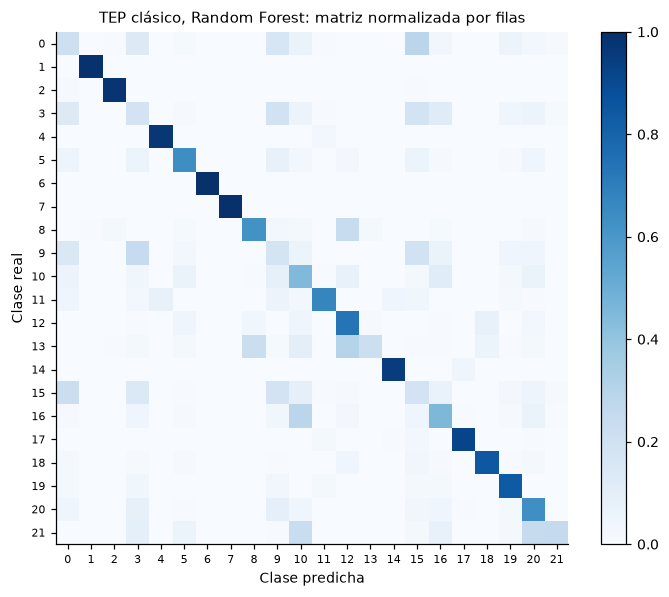

In [10]:
cm = confusion_matrix(y_te, pred_cl["RF"], labels=CLASES_CL, normalize="true")
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(CLASES_CL); ax.set_yticks(CLASES_CL)
ax.set_xticklabels(CLASES_CL, fontsize=7); ax.set_yticklabels(CLASES_CL, fontsize=7)
ax.set_xlabel("Clase predicha"); ax.set_ylabel("Clase real"); ax.grid(False)
ax.set_title("TEP clásico, Random Forest: matriz normalizada por filas")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

**Cómo leerlo.** Una diagonal oscura es un fallo bien diagnosticado. Busca ahora las filas 0, 3, 9 y 15: en ellas la diagonal apenas se ve, y buena parte de la masa cae en las columnas 0, 3, 9 y 15, formando un bloque de confusión mutua. Para el clasificador son casi una sola clase, «nada visible», y reparte entre ellas. La sección 6 lo cuantifica.

### 5.3 Por qué el «f1» por fallo del cuaderno 02 anterior no es un F1 (defecto B3)

El cuaderno 02 guardaba, por fallo, `f1_score(y_te[m], y_p[m], labels=[fallo])`, con `m = y_te == fallo`. Es decir, el F1 calculado **solo sobre las muestras cuya clase real es ese fallo**. Ahí no puede haber falsos positivos de otras clases, porque no hay otras clases. La precisión sale 1 y el «F1» se queda en 2·1·r/(1 + r) = 2r/(1 + r): una función del recall que siempre es mayor o igual que el F1 de verdad. La celda lo comprueba con tus tres clasificadores.

In [11]:
filas = []
for m, y_p in pred_cl.items():
    rec = recall_score(y_te, y_p, labels=CLASES_CL, average=None, zero_division=0)
    f1_real = f1_score(y_te, y_p, labels=CLASES_CL, average=None, zero_division=0)
    # El cálculo del 02 anterior: F1 restringido a las muestras de cada clase real.
    f1_viejo = np.array([f1_score(y_te[y_te == c], y_p[y_te == c], labels=[c], average="macro",
                                  zero_division=0) for c in CLASES_CL])
    filas.append({"method": m,
                  "máx |f1_viejo - 2r/(1+r)|": np.abs(f1_viejo - 2 * rec / (1 + rec)).max(),
                  "media de f1_viejo": f1_viejo.mean(),
                  "macro-F1 real": f1_real.mean(),
                  "inflado (viejo - real)": f1_viejo.mean() - f1_real.mean(),
                  "inflado medio en 3, 9 y 15": (f1_viejo - f1_real)[list(metrics.HARD_FAULTS)].mean()})
pd.DataFrame(filas).set_index("method").round(4)

,máx |f1_viejo - 2r/(1+r)|,media de f1_viejo,macro-F1 real,inflado (viejo - real),"inflado medio en 3, 9 y 15"
method,,,,,
kNN,0.0,0.4694,0.3920,0.0775,0.1101
SVM,0.0,0.5970,0.5063,0.0908,0.1656
RF,0.0,0.7256,0.6311,0.0944,0.1386


In [12]:
# Detalle para el Random Forest: dónde se esconde el inflado.
rf = por_clase_cl[por_clase_cl["method"] == "RF"].set_index("faultNumber")
rf["f1_viejo = 2r/(1+r)"] = 2 * rf["recall"] / (1 + rf["recall"])
rf.loc[[0, 3, 9, 15, 1, 6], ["recall", "precision", "f1", "f1_viejo = 2r/(1+r)"]].round(3)

,recall,precision,f1,f1_viejo = 2r/(1+r)
faultNumber,,,,
0,0.211,0.252,0.230,0.349
3,0.182,0.161,0.171,0.309
9,0.172,0.148,0.159,0.294
15,0.182,0.151,0.165,0.309
1,0.990,0.995,0.992,0.995
6,0.998,1.000,0.999,0.999


**Cómo leerlo.** La primera columna de la tabla de arriba es cero, o del orden del redondeo de la máquina: el «f1» viejo es exactamente 2r/(1+r), no un F1. La cuarta columna es cuánto inflaba la media en cada clasificador, y la quinta, cuánto inflaba en los fallos 3, 9 y 15: compárala con la cuarta y verás que el inflado se concentra en los fallos difíciles. En el detalle del Random Forest, compara las columnas `f1` y `f1_viejo`. En los fallos fáciles (1 y 6) casi coinciden, porque su precisión ronda 1. En la clase normal y en 3, 9 y 15 se separan, porque son las clases con menos precisión: reciben las muestras que el clasificador no sabe dónde poner. Es el tipo de inflado que el TFM denuncia, y estaba en la plantilla que ibas a copiar para Rieth; `metrics.aggregate` le habría puesto intervalos de confianza a una métrica equivocada.

### Verifícalo tú: un caso de juguete

Tres clases con 10 muestras cada una. El clasificador acierta 8 de las 10 de la clase 1, pero además llama «1» a 6 muestras de la clase 2. Antes de ejecutar, calcula a mano la precisión, el recall y el F1 de la clase 1.

In [13]:
y_real = np.repeat([0, 1, 2], 10)
y_pred = y_real.copy()
y_pred[10:12] = 0              # clase 1: falla 2 de 10
y_pred[20:26] = 1              # 6 muestras de la clase 2 predichas como 1: falsos positivos de la clase 1
m1 = y_real == 1
r1 = recall_score(y_real, y_pred, labels=[1], average="macro")
print("F1 restringido a la clase real 1 (el cálculo viejo):", round(f1_score(y_real[m1], y_pred[m1], labels=[1], average="macro"), 3))
print("2r/(1+r) con el recall de la clase 1             :", round(2 * r1 / (1 + r1), 3))
print("F1 de la clase 1 sobre todo el conjunto          :", round(f1_score(y_real, y_pred, labels=[1], average="macro"), 3))
# Solución de la cuenta a mano: precisión = 8 aciertos / 14 predichas como 1; recall = 8/10;
# F1 = 2pr/(p+r). Compruébalo con precision_recall_fscore_support(y_real, y_pred, labels=[1]).

F1 restringido a la clase real 1 (el cálculo viejo): 0.889
2r/(1+r) con el recall de la clase 1             : 0.889
F1 de la clase 1 sobre todo el conjunto          : 0.667


## 6. Los fallos 3, 9 y 15, aparte → `metrics.py`

`metrics.HARD_FAULTS` guarda (3, 9, 15): el escalón en la temperatura de la alimentación D, su variación aleatoria y el agarrotamiento de la válvula del condensador. Su firma en las 52 variables es tan pequeña que apenas se separa del ruido. La regla 7 obliga a reportarlos aparte: un macro-F1 que los mezcla con los otros 18 fallos no dice si un método mejora justo donde es difícil mejorar.

In [14]:
dificil = np.isin(CLASES_CL, metrics.HARD_FAULTS)
resumen_cl = pd.DataFrame({
    "macro-F1 (22 clases)":  f1_cl.mean(),
    "macro-F1 sin 3, 9, 15": f1_cl[~dificil].mean(),
    "macro-F1 de 3, 9, 15":  f1_cl[dificil].mean(),
    "F1 de la clase normal": f1_cl.loc[0],
}).round(3)
display(resumen_cl)

# ¿Con qué se confunden? Filas: clase real 0, 3, 9 y 15. Columnas: predicción agrupada.
grupo = [0, *metrics.HARD_FAULTS]
y_p = pred_cl["RF"]
sub = pd.DataFrame({f"real {c}": [np.mean(y_p[y_te == c] == k) for k in grupo]
                    + [np.mean(~np.isin(y_p[y_te == c], grupo))] for c in grupo},
                   index=[f"pred {k}" for k in grupo] + ["pred otra clase"]).T
print("Random Forest: reparto de las predicciones de cada clase real (cada fila suma 1)")
display(sub.round(3))

,macro-F1 (22 clases),"macro-F1 sin 3, 9, 15","macro-F1 de 3, 9, 15",F1 de la clase normal
method,,,,
kNN,0.392,0.440,0.087,0.142
SVM,0.506,0.563,0.150,0.138
RF,0.631,0.705,0.165,0.230


Random Forest: reparto de las predicciones de cada clase real (cada fila suma 1)


,pred 0,pred 3,pred 9,pred 15,pred otra clase
real 0,0.211,0.129,0.162,0.284,0.212
real 3,0.126,0.182,0.189,0.185,0.318
real 9,0.148,0.246,0.172,0.191,0.242
real 15,0.219,0.140,0.181,0.182,0.278


**Cómo leerlo.** En la primera tabla, compara la columna «sin 3, 9, 15» con «de 3, 9, 15»: la distancia entre ellas es lo que un macro-F1 global esconde. En la segunda (Random Forest), cada fila suma 1. La mayor parte de la masa de las filas 0, 3, 9 y 15 se queda en las columnas 0, 3, 9 y 15, y en ninguna fila la columna correcta destaca sobre las otras tres; lo que va a «otra clase» tampoco es un acierto. El clasificador no sabe cuál de los fallos invisibles tiene delante ni lo distingue de la operación normal. Es coherente con el 01, donde el PCA tampoco los detectaba: si el detector no los separa de lo normal, el clasificador tampoco tiene de dónde sacar la diferencia. Y es la prueba de cordura que conviene aplicar a cualquier artículo: **un F1 alto en 3, 9 y 15 es, antes que nada, sospecha de fuga**. La sección 7 lo muestra en directo.

## 7. El experimento de tu OE2 en miniatura: partición por muestra frente a partición por simulación → `data.py` (`load_rieth`, `split_runs`)

En el clásico no se puede hacer, porque hay una simulación por clase. En Rieth hay 500 por clase, y aquí se usa un subconjunto: `datos.runs_desarrollo` simulaciones de entrenamiento por clase (hoy, 20 en el yaml), que se cargan en segundos y ocupan poca memoria. Los resultados definitivos irán con `datos.runs_finales`.

**El experimento.** El mismo clasificador, los mismos datos y el mismo número de muestras de entrenamiento y de prueba. Solo cambia cómo se parte:

- **(a) Aleatoria por muestra.** Se juntan las muestras de todas las simulaciones y se reparten al azar (`train_test_split`, estratificado por clase). Es lo que hace buena parte de la literatura.
- **(b) Por simulación.** `data.split_runs` reparte **identificadores de simulación** entre ajuste, validación y prueba, con las fracciones del yaml, y todas las muestras de una simulación caen del mismo lado. Las simulaciones de validación se reservan y aquí no se usan: son para ajustar hiperparámetros en el **Te toca**.

**Por qué la (a) infla.** Por la autocorrelación. El proceso tiene inercia y se muestrea cada 3 minutos, así que la muestra t de una simulación se parece mucho a la t−1 y a la t+1. Con la partición (a), casi cada muestra de prueba tiene a sus vecinas temporales en el entrenamiento, y con la misma etiqueta. El clasificador puede acertar reconociendo **de qué simulación** viene la muestra, y no **qué fallo** tiene. Es como examinar a un operador con fotos del panel tomadas 3 minutos antes o después de las que ya estudió: acierta porque reconoce el turno, no porque sepa diagnosticar. La (b) responde a la pregunta que importa en planta: ¿diagnostica bien una simulación que no ha visto nunca?

**Dos cuidados de Rieth que se aplican siempre.** En los ficheros de entrenamiento con fallo, las 20 primeras muestras son anteriores al inicio del fallo y se descartan (`data.fault_onset("train", "rieth")`); quedan 480 por simulación, como en el clásico. Además, los identificadores llegan en `int16` y se pasan a `int64` antes de operar con ellos, porque en `int16` una cuenta como `simulationRun * 1000 + sample` desborda.

Se usan dos clasificadores: el kNN, el más expuesto a esta fuga, y el Random Forest, el mejor en el clásico. La SVM se queda fuera de Rieth por tiempo (sección 4).

**Todo esto es desarrollo.** Las simulaciones de Rieth que carga este cuaderno quedan miradas y no sirven para el resultado confirmatorio del OE2: esos ids se declaran antes de ejecutar (`docs/reglas_de_medida.md`, regla 3).

In [15]:
# Utilidades de las secciones 7 y 8 (definirlas no necesita datos).
ID = ["faultNumber", "simulationRun", "sample"]
CLASES_R = list(range(21))                          # Rieth no tiene el fallo 21
PA, PB = "(a) aleatoria por muestra", "(b) por simulación"
METODOS_R = {"kNN": FABRICAS["kNN"], "RF": FABRICAS["RF"]}

def cargar_pool(split, ids_por_clase, descartar_prefallo=True):
    """Apila las 21 clases de Rieth con las simulaciones pedidas para cada una."""
    onset = data.fault_onset(split, "rieth")        # 20 en entrenamiento, 160 en prueba
    partes = []
    for k in CLASES_R:
        ids = [int(i) for i in ids_por_clase[k]]    # enteros de Python
        d = data.load_rieth(k, split, runs=ids, root=RIETH_DIR)
        if k > 0 and descartar_prefallo:
            d = d[d["sample"] > onset]              # antes del inicio, la simulación aún es normal
        partes.append(d)
    pool = pd.concat(partes, ignore_index=True)
    pool[ID] = pool[ID].astype("int64")             # int16 -> int64 antes de operar con los ids
    pool = pool.sort_values(ID, ignore_index=True)
    # load_rieth ignora sin avisar los ids que no existen: se comprueba que llegaron todos.
    llegan = pool.groupby("faultNumber")["simulationRun"].nunique()
    assert all(llegan[k] == len(ids_por_clase[k]) for k in CLASES_R), "faltan simulaciones"
    return pool

def particiones(pool):
    """Las dos particiones del experimento, con el mismo tamaño de entrenamiento y de prueba."""
    y = pool["faultNumber"].to_numpy()
    # Posición de cada simulación dentro de su clase (1..RUNS_DEV) y reparto por simulación.
    pos = pool.groupby("faultNumber")["simulationRun"].rank(method="dense").astype(int).to_numpy()
    p_tr, p_va, p_te = data.split_runs(RUNS_DEV, fractions=FRACCIONES, seed=SEMILLA)
    i_tr_b, i_te_b = np.flatnonzero(np.isin(pos, p_tr)), np.flatnonzero(np.isin(pos, p_te))
    # (a): las mismas simulaciones de ajuste y de prueba, repartidas al azar muestra a muestra.
    usadas = np.concatenate([i_tr_b, i_te_b])
    i_tr_a, i_te_a = train_test_split(usadas, test_size=i_te_b.size / usadas.size,
                                      stratify=y[usadas], random_state=SEMILLA)
    return {PA: (i_tr_a, i_te_a), PB: (i_tr_b, i_te_b)}, (p_tr, p_va, p_te)

def evaluar(fabrica, X, y, i_tr, i_te):
    """Escala con el entrenamiento de ESTA partición, entrena y predice (reglas 1 y 2)."""
    esc = Scaler().fit(X[i_tr])
    modelo = fabrica().fit(esc.transform(X[i_tr]), y[i_tr])
    return modelo.predict(esc.transform(X[i_te])), modelo, esc

def resumen_f1(y_true, y_pred):
    """macro-F1 global, sin 3/9/15 y de 3/9/15 (reglas 5 y 7), más el F1 de cada clase."""
    f1 = f1_score(y_true, y_pred, labels=CLASES_R, average=None, zero_division=0)
    dif = np.isin(CLASES_R, metrics.HARD_FAULTS)
    return {"macro_f1": f1.mean(), "macro_f1_sin_3_9_15": f1[~dif].mean(),
            "macro_f1_3_9_15": f1[dif].mean()}, f1

def experimento(pool, diseno, guardar=()):
    """(a) frente a (b) con kNN y RF. Devuelve la tabla, el F1 por clase y los modelos pedidos."""
    X, y = data.values(pool), pool["faultNumber"].to_numpy()
    parts, _ = particiones(pool)
    filas, f1s, modelos = [], {}, {}
    for metodo, fabrica in METODOS_R.items():
        for nombre, (i_tr, i_te) in parts.items():
            t = time.perf_counter()
            y_pred, modelo, esc = evaluar(fabrica, X, y, i_tr, i_te)
            res, f1s[(metodo, nombre)] = resumen_f1(y[i_te], y_pred)
            filas.append({"diseno": diseno, "method": metodo, "particion": nombre, **res,
                          "n_train": i_tr.size, "n_test": i_te.size,
                          "segundos": round(time.perf_counter() - t, 1)})
            if (metodo, nombre) in guardar:
                modelos[(metodo, nombre)] = (modelo, esc)
            del modelo; gc.collect()                # un Random Forest de Rieth ocupa cientos de MB
    return pd.DataFrame(filas), f1s, modelos, parts

def tabla_diferencia(t):
    """macro-F1 con (a) y con (b) y su diferencia, calculada aquí y no a mano."""
    cols = ["macro_f1", "macro_f1_sin_3_9_15", "macro_f1_3_9_15"]
    w = t.pivot(index="method", columns="particion", values=cols)
    for c in cols:
        w[(c, "(a) − (b)")] = w[(c, PA)] - w[(c, PB)]
    return w[[(c, p) for c in cols for p in (PA, PB, "(a) − (b)")]].round(3)

def figura_diferencias(f1s, titulo):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
    colores = [plots.COLORS["fault"] if c in metrics.HARD_FAULTS else plots.COLORS["normal"] for c in CLASES_R]
    for ax, metodo in zip(axes, METODOS_R):
        ax.bar(CLASES_R, f1s[(metodo, PA)] - f1s[(metodo, PB)], color=colores)
        ax.axhline(0, color=plots.COLORS["limit"], lw=0.8)
        ax.set_xticks(CLASES_R); ax.set_xlabel("Clase (0 = normal); en rojo, 3, 9 y 15")
        ax.set_title(f"{metodo}: F1 con (a) menos F1 con (b)")
    axes[0].set_ylabel("Diferencia de F1")
    fig.suptitle(titulo, fontsize=10); plt.tight_layout()

def procedencia_vecino(pool, parts, modelos_knn, n=2000):
    """Para n muestras de prueba de cada partición: ¿de dónde sale su vecino más cercano?"""
    X = data.values(pool)
    F, R, S = (pool[c].to_numpy() for c in ID)
    rng = np.random.default_rng(SEMILLA)
    filas = []
    for nombre, (i_tr, i_te) in parts.items():
        modelo, esc = modelos_knn[nombre]
        q = rng.choice(i_te, size=min(n, i_te.size), replace=False)
        Zq = esc.transform(X[q])
        _, j = modelo.kneighbors(Zq, n_neighbors=1)
        v = i_tr[j[:, 0]]                                   # posición del vecino en el pool
        misma = (F[v] == F[q]) & (R[v] == R[q])             # misma clase y misma simulación
        gemela = (F[v] != F[q]) & (R[v] == R[q])            # mismo id de simulación, otra clase
        acierto = modelo.predict(Zq) == F[q]                # el voto real del kNN (k = 5)
        media = lambda a, m: a[m].mean() if m.any() else np.nan
        for grupo, g in (("todas las clases", np.ones(q.size, bool)),
                         ("clases 0, 3, 9 y 15", np.isin(F[q], [0, *metrics.HARD_FAULTS]))):
            filas.append({"particion": nombre, "consultas": grupo,
                          "vecino: misma simulación": misma[g].mean(),
                          "vecino: gemela de otra clase": gemela[g].mean(),
                          "vecino: otra simulación": 1 - misma[g].mean() - gemela[g].mean(),
                          "|Δ muestra| mediana (misma sim.)":
                              np.median(np.abs(S[v] - S[q])[g & misma]) if (g & misma).any() else np.nan,
                          "acierto kNN (vecino de la misma sim.)": media(acierto, g & misma),
                          "acierto kNN (resto)": media(acierto, g & ~misma)})
    return pd.DataFrame(filas).set_index(["particion", "consultas"]).round(3)

RES_PARTICION = []      # se llena en la sección 7 y se guarda en la 8
print("Utilidades listas.", "Hay datos de Rieth." if HAY_RIETH else SIN_RIETH)

Utilidades listas. Hay datos de Rieth.


### 7.1 Diseño limpio: una simulación distinta para cada clase

Primero, el experimento con una sola cosa cambiando. Para que ninguna simulación de una clase tenga relación con las de otra, cada clase toma su propio bloque de identificadores: la clase k usa las simulaciones de k·N + 1 a (k+1)·N, con N = `RUNS_DEV`. En la 7.2 verás por qué hace falta este cuidado.

In [16]:
if not HAY_RIETH:
    print(SIN_RIETH)
else:
    assert 21 * RUNS_DEV <= 500, "con este RUNS_DEV no caben bloques disjuntos de identificadores"
    ids_disjuntos = {k: range(k * RUNS_DEV + 1, (k + 1) * RUNS_DEV + 1) for k in CLASES_R}
    pool_d = cargar_pool("train", ids_disjuntos)
    por_sim_d = pool_d.groupby(ID[:2]).size()
    print("Pool:", pool_d.shape, "| simulaciones por clase:",
          pool_d.groupby("faultNumber")["simulationRun"].nunique().unique().tolist(),
          "| muestras por simulación (normal / con fallo):",
          por_sim_d.loc[0].unique().tolist(), "/", por_sim_d.drop(index=0).unique().tolist())
    _, (p_tr, p_va, p_te) = particiones(pool_d)
    print("Posición de la simulación dentro de su clase -> ajuste:", p_tr.tolist())
    print("   validación (reservada, no se usa):", p_va.tolist(), "| prueba:", p_te.tolist())

Pool: (202000, 55) | simulaciones por clase: [20] | muestras por simulación (normal / con fallo): [500] / [480]
Posición de la simulación dentro de su clase -> ajuste: [1, 4, 6, 7, 8, 10, 11, 13, 15, 16, 17, 20]
   validación (reservada, no se usa): [3, 5, 12, 19] | prueba: [2, 9, 14, 18]


,method,particion,n_train,n_test,segundos
0,kNN,(a) aleatoria por muestra,121200,40400,24.5
1,kNN,(b) por simulación,121200,40400,24.0
2,RF,(a) aleatoria por muestra,121200,40400,69.2
3,RF,(b) por simulación,121200,40400,12.5


macro_f1                                    macro_f1_sin_3_9_15                                        macro_f1_3_9_15  \
particion (a) aleatoria por muestra (b) por simulación (a) − (b) (a) aleatoria por muestra (b) por simulación (a) − (b) (a) aleatoria por muestra   
method                                                                                                                                              
RF                            0.831              0.762     0.069                     0.898              0.855     0.042                     0.429   
kNN                           0.526              0.479     0.047                     0.593              0.543     0.050                     0.123   

                                        
particion (b) por simulación (a) − (b)  
method                                  
RF                     0.202     0.228  
kNN                    0.095     0.027

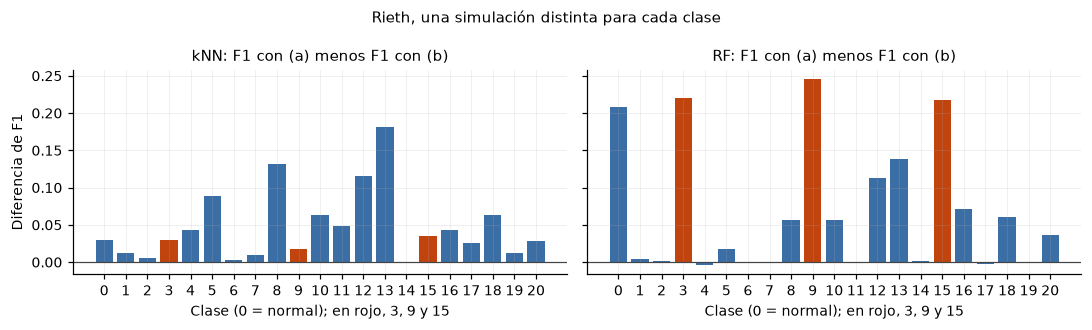

In [17]:
if not HAY_RIETH:
    print(SIN_RIETH)
else:
    t_d, f1s_d, modelos_d, parts_d = experimento(pool_d, "ids distintos por clase",
                                                 guardar={("kNN", PA), ("kNN", PB)})
    RES_PARTICION.append(t_d)
    display(t_d[["method", "particion", "n_train", "n_test", "segundos"]])
    display(tabla_diferencia(t_d))
    figura_diferencias(f1s_d, "Rieth, una simulación distinta para cada clase")

**Cómo leerlo.** Primero comprueba en la tabla pequeña que (a) y (b) entrenan y prueban con el mismo número de muestras: la comparación es justa. Después, en la tabla de diferencias, mira la columna «(a) − (b)» del macro-F1. Es el efecto de partir por muestra, calculado por la celda. Fíjate en dos cosas. La primera, el signo en los dos clasificadores: la (a) promete más de lo que la (b) confirma. La segunda, el bloque de 3, 9 y 15 del Random Forest: ahí es donde la partición por muestra más «mejora» el resultado, justo en los fallos que la física dice casi invisibles. Es la prueba de cordura de la sección 6 en directo. En las barras, la mayoría de las clases queda por encima de cero, y las que apenas se mueven son las que ya estaban cerca del techo.

### ¿De dónde sale el vecino más cercano?

La explicación de arriba es una hipótesis hasta que se mira. La celda toma una muestra aleatoria de puntos de prueba de cada partición (el argumento `n`) y busca, con el propio kNN, su vecino más cercano en el entrenamiento.

In [18]:
if not HAY_RIETH:
    print(SIN_RIETH)
else:
    display(procedencia_vecino(pool_d, parts_d, {p: modelos_d[("kNN", p)] for p in (PA, PB)}))

vecino: misma simulación  vecino: gemela de otra clase  vecino: otra simulación  \
particion                 consultas                                                                                              
(a) aleatoria por muestra todas las clases                        0.255                           0.0                    0.745   
                          clases 0, 3, 9 y 15                     0.072                           0.0                    0.928   
(b) por simulación        todas las clases                        0.000                           0.0                    1.000   
                          clases 0, 3, 9 y 15                     0.000                           0.0                    1.000   

                                               |Δ muestra| mediana (misma sim.)  acierto kNN (vecino de la misma sim.)  acierto kNN (resto)  
particion                 consultas                                                                                                          
(a) aleatoria por muestra todas las clases                                  1.0                                  0.865                0.368  
                          clases 0, 3, 9 y 15                               1.0                                  0.593                0.166  
(b) por simulación        todas las clases                                  NaN                                    NaN                0.438  
                          clases 0, 3, 9 y 15                               NaN                                    NaN                0.142

**Cómo leerlo.** Con la partición (a), una parte de las muestras de prueba tiene como vecino más cercano a otra muestra **de la misma simulación**, y la columna «|Δ muestra|» dice a qué distancia está: una sola muestra, la foto de 3 minutos antes o después. En esas consultas el kNN acierta mucho más que en el resto (compara las dos columnas de acierto): son aciertos que no salen de saber diagnosticar, sino de haber visto la muestra de al lado. No hace falta que sean la mayoría; basta con que una fracción de la prueba se apruebe así para que la media suba. Con la (b), por construcción, no hay ninguna. Ahí tienes el mecanismo del inflado medido, no supuesto.

En las clases 0, 3, 9 y 15 esa fracción es más pequeña, porque el vecino puede caer en muchas simulaciones de cuatro clases casi indistinguibles. El Random Forest, que no decide por un único vecino, es justo el que más infla en 3, 9 y 15. Una hipótesis que puedes comprobar: aprende rasgos propios de cada simulación (su deriva lenta, por ejemplo), que la partición (a) le deja ver a los dos lados. La columna «gemela de otra clase» vale cero porque en este diseño ninguna clase comparte identificadores con otra. En el apartado siguiente deja de valer cero.

### Verifícalo tú: ¿y con un solo vecino?

¿Crece o se encoge la diferencia (a) − (b) del kNN si usas un solo vecino (k = 1)? Piensa la respuesta con el mecanismo de arriba antes de ejecutar la solución.

In [19]:
# Verifícalo tú (solución comentada; tarda unos segundos).
# if HAY_RIETH:
#     X_d, y_d = data.values(pool_d), pool_d["faultNumber"].to_numpy()
#     for nombre, (i_tr, i_te) in parts_d.items():
#         y_pred, _, _ = evaluar(lambda: KNeighborsClassifier(n_neighbors=1), X_d, y_d, i_tr, i_te)
#         print(nombre, round(f1_score(y_d[i_te], y_pred, average="macro"), 3))
# Pista para interpretarlo: con k = 1 el voto lo decide un único vecino, que en (a) suele ser la
# muestra contigua de la misma simulación. Compara con la tabla de diferencias de arriba.

### 7.2 La trampa de las gemelas: en Rieth, la simulación r de cada clase comparte semilla con la normal r

Lo natural al cargar Rieth es pedir las simulaciones 1 a N de todas las clases (`runs=N`). Pero en Rieth la simulación con fallo número r y la normal número r del mismo fichero **comparten semilla**: son la misma trayectoria hasta que entra el fallo. Después, si el fallo deja poca huella, siguen casi pegadas. La celda lo comprueba con la simulación 1 de cuatro fallos: el 1, que deja una huella grande, y los tres difíciles. Las distancias están en unidades de la desviación normal de cada variable.

In [20]:
if not HAY_RIETH:
    print(SIN_RIETH)
else:
    ONSET_TR_R = data.fault_onset("train", "rieth")            # 20
    normal = data.load_rieth(0, "train", runs=[1, 2], root=RIETH_DIR)
    n1 = data.values(normal[normal["simulationRun"] == 1])
    n2 = data.values(normal[normal["simulationRun"] == 2])
    sd = data.values(normal).std(axis=0, ddof=1)                 # escala: la variabilidad normal
    filas = []
    for f in (1, *metrics.HARD_FAULTS):
        x = data.values(data.load_rieth(f, "train", runs=[1], root=RIETH_DIR))
        filas.append({"simulación 1 de": f"fallo {f}",
                      "antes del inicio, ¿idéntica a la normal 1?": np.array_equal(x[:ONSET_TR_R], n1[:ONSET_TR_R]),
                      "|Δz| medio tras el inicio, frente a la normal 1": (np.abs(x[ONSET_TR_R:] - n1[ONSET_TR_R:]) / sd).mean()})
    filas.append({"simulación 1 de": "normal 2 (otra semilla)",
                  "antes del inicio, ¿idéntica a la normal 1?": np.array_equal(n2[:ONSET_TR_R], n1[:ONSET_TR_R]),
                  "|Δz| medio tras el inicio, frente a la normal 1": (np.abs(n2[ONSET_TR_R:] - n1[ONSET_TR_R:]) / sd).mean()})
    display(pd.DataFrame(filas).set_index("simulación 1 de").round(3))

,"antes del inicio, ¿idéntica a la normal 1?","|Δz| medio tras el inicio, frente a la normal 1"
simulación 1 de,,
fallo 1,True,2.171
fallo 3,True,0.015
fallo 9,True,0.055
fallo 15,True,0.091
normal 2 (otra semilla),False,1.197


**Cómo leerlo.** La primera columna dice que, antes del inicio del fallo, la simulación con fallo es una copia exacta de su gemela normal; por eso esas filas se descartan, porque serían muestras normales con etiqueta de fallo. La segunda compara la distancia tras el inicio con la que hay entre dos simulaciones normales **distintas** (la última fila). En el fallo 1 la trayectoria se va lejos; en el 3, el 9 y el 15 se queda mucho más cerca de su gemela que cualquier otra simulación normal. Ahora piensa qué hace la partición (a) con esto. Si cargas los ids 1 a N para todas las clases, la muestra t de «fallo 3, simulación r» puede ir a prueba mientras su gemela «normal, simulación r, muestra t», casi idéntica, va a entrenamiento **con otra etiqueta**. La celda siguiente repite el experimento con ese diseño.

macro_f1                                    macro_f1_sin_3_9_15                                        macro_f1_3_9_15  \
particion (a) aleatoria por muestra (b) por simulación (a) − (b) (a) aleatoria por muestra (b) por simulación (a) − (b) (a) aleatoria por muestra   
method                                                                                                                                              
RF                            0.748              0.728     0.020                     0.870              0.815     0.055                     0.020   
kNN                           0.438              0.494    -0.056                     0.511              0.568    -0.056                     0.001   

                                        
particion (b) por simulación (a) − (b)  
method                                  
RF                     0.208    -0.188  
kNN                    0.053    -0.052

vecino: misma simulación  vecino: gemela de otra clase  vecino: otra simulación  \
particion                 consultas                                                                                              
(a) aleatoria por muestra todas las clases                        0.209                         0.558                    0.233   
                          clases 0, 3, 9 y 15                     0.003                         0.989                    0.008   
(b) por simulación        todas las clases                        0.000                         0.000                    1.000   
                          clases 0, 3, 9 y 15                     0.000                         0.000                    1.000   

                                               |Δ muestra| mediana (misma sim.)  acierto kNN (vecino de la misma sim.)  acierto kNN (resto)  
particion                 consultas                                                                                                          
(a) aleatoria por muestra todas las clases                                  1.0                                  0.931                0.241  
                          clases 0, 3, 9 y 15                               1.0                                  1.000                0.011  
(b) por simulación        todas las clases                                  NaN                                    NaN                0.468  
                          clases 0, 3, 9 y 15                               NaN                                    NaN                0.187

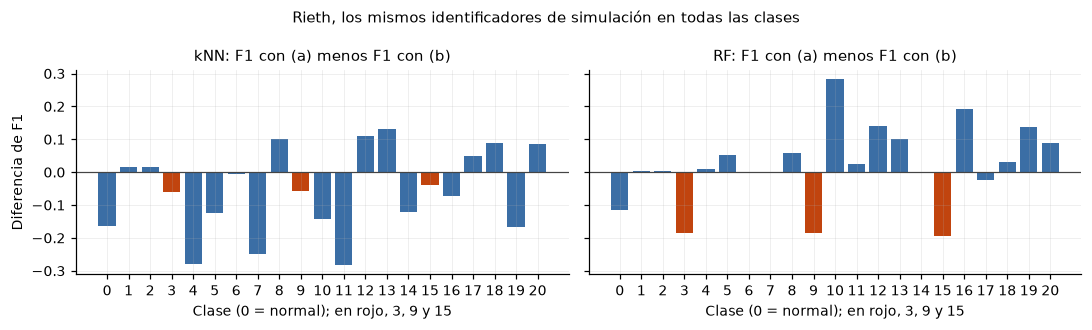

In [21]:
if not HAY_RIETH:
    print(SIN_RIETH)
else:
    del pool_d, modelos_d, parts_d; gc.collect()                  # se libera el diseño anterior
    ids_compartidos = {k: range(1, RUNS_DEV + 1) for k in CLASES_R}   # lo mismo que runs=RUNS_DEV
    pool_c = cargar_pool("train", ids_compartidos)
    t_c, f1s_c, modelos_c, parts_c = experimento(
        pool_c, "mismos ids en todas las clases",
        guardar={("kNN", PA), ("kNN", PB), ("RF", PB)})           # los (b) se reutilizan en la sección 8
    RES_PARTICION.append(t_c)
    display(tabla_diferencia(t_c))
    figura_diferencias(f1s_c, "Rieth, los mismos identificadores de simulación en todas las clases")
    display(procedencia_vecino(pool_c, parts_c, {p: modelos_c[("kNN", p)] for p in (PA, PB)}))

**Cómo leerlo.** Ahora la partición (a) mezcla dos efectos de signo contrario:
- **La autocorrelación, que infla**, igual que en la 7.1.
- **Las gemelas, que desinflan.** En la tabla de procedencia, mira la columna «vecino: gemela de otra clase» con la partición (a). Para las clases 0, 3, 9 y 15, el vecino más cercano es casi siempre la gemela de otra clase, es decir, la misma simulación y la misma muestra con otra etiqueta. El clasificador reconoce el «turno» y falla la etiqueta.

En el Random Forest el dibujo es nítido: fuera de 0, 3, 9 y 15, las barras quedan casi todas por encima de cero (la autocorrelación), y en esas cuatro clases se hunden (las gemelas). En el kNN las gemelas pesan en muchas más clases, porque decide solo por cercanía y, con los ids compartidos, la gemela está más a menudo cerca que la vecina temporal: mira la fila «todas las clases» de la tabla. Por eso la diferencia neta del macro-F1 (columna «(a) − (b)») sale con signo distinto en los dos clasificadores, y distinta de la de la 7.1.

La conclusión para tu OE2 es más fuerte que «la partición por muestra infla»: **su error no tiene un signo fijo**. Depende de cómo se generó el conjunto de datos y del clasificador, así que no se puede corregir a posteriori. Solo la (b) estima lo que importa. De aquí sale además un cuidado operativo: en Rieth, la validación cruzada por grupos (*GroupKFold*) se hace con `groups = simulationRun`, compartido entre clases, **nunca** con la clave (fallo, simulación), que separaría a las gemelas.

### Un matiz del inicio: nominal frente a efectivo

La tabla de la 7.2 dice que, antes del inicio, cada simulación con fallo es copia exacta de su gemela normal. ¿Y justo después? Si el fallo tarda en mover alguna de las 52 variables, las primeras muestras «con fallo» siguen siendo idénticas a la operación normal, y al descartar solo `sample <= 20` se quedan en el entrenamiento con etiqueta de fallo. La celda lo mide en el pool de la 7.2: para cada fallo y cada simulación, cuántas muestras pasan desde la primera posterior al inicio hasta la primera distinta de su gemela, y qué fracción de las filas que se conservan es idéntica a la clase 0.

In [22]:
# Regla 6, matiz de la verificación del 27/09 (DAT-1): el inicio nominal no siempre es el efectivo.
def separacion_de_la_gemela(fallos, normal, onset):
    """Para cada fallo: cuántas muestras después del inicio nominal sigue cada simulación idéntica,
    en las 52 variables, a la simulación normal con el mismo id (su gemela).

    fallos: {fallo: DataFrame de ese fallo}; normal: DataFrame de la clase 0 con los mismos ids.
    retraso = 0 si la simulación ya es distinta en la primera muestra posterior al inicio."""
    clave = ["simulationRun", "sample"]
    norm = normal.loc[normal["sample"] > onset, clave + data.VAR_NAMES]
    filas = []
    for k, d in fallos.items():
        post = d.loc[d["sample"] > onset, clave + data.VAR_NAMES]
        m = post.merge(norm, on=clave, suffixes=("", "_gemela"))
        assert len(m) == len(post), "falta la gemela normal de alguna fila"
        igual = (m[data.VAR_NAMES].to_numpy()
                 == m[[v + "_gemela" for v in data.VAR_NAMES]].to_numpy()).all(axis=1)
        m = m[clave].assign(igual=igual)
        retraso = m[~m["igual"]].groupby("simulationRun")["sample"].min() - (onset + 1)
        n_sim = m["simulationRun"].nunique()
        filas.append({"faultNumber": k, "simulaciones": n_sim, "sin separarse": n_sim - retraso.size,
                      "retraso mínimo": retraso.min(), "retraso mediano": retraso.median(),
                      "retraso máximo": retraso.max(),
                      "fracción de filas post-inicio idénticas": igual.mean()})
    return pd.DataFrame(filas).set_index("faultNumber")

if not HAY_RIETH:
    print(SIN_RIETH)
else:
    sep_train = separacion_de_la_gemela(
        {k: pool_c[pool_c["faultNumber"] == k] for k in CLASES_R[1:]},
        pool_c[pool_c["faultNumber"] == 0], data.fault_onset("train", "rieth"))
    print(f"Ficheros de entrenamiento, simulaciones 1 a {RUNS_DEV}: retraso en muestras desde la "
          "primera posterior al inicio hasta la primera distinta de la gemela")
    display(sep_train.round(3))


Ficheros de entrenamiento, simulaciones 1 a 20: retraso en muestras desde la primera posterior al inicio hasta la primera distinta de la gemela


,simulaciones,sin separarse,retraso mínimo,retraso mediano,retraso máximo,fracción de filas post-inicio idénticas
faultNumber,,,,,,
1,20,0,0,0.0,0,0.000
2,20,0,0,0.0,0,0.000
3,20,0,0,0.0,0,0.000
4,20,0,0,0.0,0,0.000
5,20,0,0,0.0,0,0.000
6,20,0,0,0.0,0,0.000
7,20,0,0,0.0,0,0.000
8,20,0,1,2.5,8,0.007
9,20,0,0,7.5,13,0.015


**Cómo leerlo.** Busca los fallos donde el retraso mínimo no es cero: en ellos ninguna simulación se separa de su gemela en la primera muestra con fallo. La última columna es la fracción de filas con etiqueta de fallo que son copia exacta de la clase 0: ningún clasificador que mire muestra a muestra puede distinguirlas de su gemela normal (lo que acierte en una lo falla en la otra), y en entrenamiento enseñan una etiqueta falsa. Es ruido de etiqueta. Si la fracción es pequeña, basta con declararlo; si no, la decisión de descartar ese tramo va a `decisiones.md` antes de lo confirmatorio, igual para los tres bloques. Y no confundas separarse con alejarse: una simulación puede dejar de ser idéntica a su gemela y seguir pegada a ella, como el 3, el 9 y el 15 en la tabla de la 7.2.

## 8. Formato común de resultados y un contraste → `metrics.py` y `stats.py`

Todo lo anterior se guarda en el formato común de la regla 11, en `results/raw/` (prueba de humo, que git ignora):

| Fichero | Una fila por | Qué contiene |
|---|---|---|
| `B00_clasico_por_clase.csv` | método y clase | precisión, recall y F1 de cada clase sobre toda la prueba del clásico. Como hay una simulación por clase, el recall por (fallo, simulación) y el recall por clase coinciden |
| `B00_rieth_particion.csv` | diseño, método y partición | los macro-F1 de la sección 7 |
| `B00_rieth_por_simulacion.csv` | (`method`, `faultNumber`, `simulationRun`) | el recall del diagnóstico en esa simulación y las columnas de `evaluate_run`, con el clasificador como detector |
| `B00_rieth_por_clase.csv` | método y clase | precisión, recall y F1 de cada clase sobre el pool de prueba de Rieth |

**La prueba de Rieth.** Los modelos (b) de la 7.2, entrenados con las simulaciones de ajuste de los ficheros de entrenamiento, se evalúan sobre los **ficheros de prueba** de Rieth: 960 muestras por simulación, con el fallo tras la 160. Los ficheros de prueba no comparten semillas con los de entrenamiento, así que no hay fuga. Se toman las simulaciones 1 a `RUNS_EVAL`, la mitad de `RUNS_DEV`, para que la predicción del kNN no se alargue. En el diagnóstico cuentan las muestras posteriores al inicio (y todas las de la clase normal); en la detección, la simulación entera, y cada muestra que el clasificador no llama «normal» es una alarma.

In [23]:
RAW = Path("results/raw")
RAW.mkdir(parents=True, exist_ok=True)
COLS_CLASE = ["method", "faultNumber", "simulationRun", "precision", "recall", "f1", "support"]

# TEP clásico: una simulación por clase, así que simulationRun = 1.
(por_clase_cl.assign(simulationRun=1)[COLS_CLASE]
    .assign(fuente="classic", semilla=SEMILLA)
    .to_csv(RAW / "B00_clasico_por_clase.csv", index=False))
print("Escrito", RAW / "B00_clasico_por_clase.csv")

if RES_PARTICION:
    (pd.concat(RES_PARTICION, ignore_index=True)
       .assign(fuente="rieth_train", runs_por_clase=RUNS_DEV, fracciones=str(FRACCIONES), semilla=SEMILLA)
       .to_csv(RAW / "B00_rieth_particion.csv", index=False))
    print("Escrito", RAW / "B00_rieth_particion.csv")

Escrito results\raw\B00_clasico_por_clase.csv
Escrito results\raw\B00_rieth_particion.csv


In [24]:
if not HAY_RIETH:
    print(SIN_RIETH)
else:
    RUNS_EVAL = RUNS_DEV // 2
    ONSET_TE_R = data.fault_onset("test", "rieth")               # 160
    prueba = cargar_pool("test", {k: range(1, RUNS_EVAL + 1) for k in CLASES_R}, descartar_prefallo=False)
    assert (prueba.groupby(ID[:2]).size() == 960).all()          # simulaciones completas
    X_p = data.values(prueba)
    F_p, R_p, S_p = (prueba[c].to_numpy() for c in ID)
    pred_p = {}
    for metodo in METODOS_R:
        modelo, esc = modelos_c[(metodo, PB)]                     # entrenado con la partición (b)
        t = time.perf_counter()
        pred_p[metodo] = modelo.predict(esc.transform(X_p))
        print(f"{metodo}: {X_p.shape[0]} muestras predichas en {time.perf_counter() - t:.1f} s")
    print("Simulaciones de prueba por clase:", RUNS_EVAL)

kNN: 201600 muestras predichas en 115.7 s


RF: 201600 muestras predichas en 4.7 s
Simulaciones de prueba por clase: 10


In [25]:
if not HAY_RIETH:
    print(SIN_RIETH)
else:
    grupos = prueba.groupby(ID[:2]).indices                       # (fallo, simulación) -> filas en orden
    filas = []
    for metodo, pred in pred_p.items():
        for (f, r), idx in grupos.items():
            p = pred[idx]
            onset = None if f == 0 else ONSET_TE_R               # el fichero normal es todo sano
            diag = p if f == 0 else p[ONSET_TE_R:]               # lo que cuenta para el diagnóstico
            alarma = (p != 0).astype(float)                      # detector: "no es normal" = alarma
            filas.append({"method": metodo, "faultNumber": f, "simulationRun": r,
                          "n_diag": diag.size, "recall": np.mean(diag == f),
                          **metrics.evaluate_run(alarma, 0.5, onset, k=K_ALARMAS, sample_minutes=MINUTOS)})
    por_sim = pd.DataFrame(filas)

    en_pool = (F_p == 0) | (S_p > ONSET_TE_R)                    # pool de diagnóstico
    por_clase_r = pd.concat([tabla_por_clase(F_p[en_pool], pred[en_pool], CLASES_R, m)
                             for m, pred in pred_p.items()], ignore_index=True)

    extra = dict(fuente="rieth_test", runs_eval=RUNS_EVAL, runs_desarrollo=RUNS_DEV,
                 fracciones=str(FRACCIONES), semilla=SEMILLA)
    por_sim.assign(**extra).to_csv(RAW / "B00_rieth_por_simulacion.csv", index=False)
    por_clase_r.assign(**extra).to_csv(RAW / "B00_rieth_por_clase.csv", index=False)
    print("Escritos B00_rieth_por_simulacion.csv", por_sim.shape, "y B00_rieth_por_clase.csv", por_clase_r.shape)
    display(por_sim.head(3))

Escritos B00_rieth_por_simulacion.csv (420, 14) y B00_rieth_por_clase.csv (42, 6)


,method,faultNumber,simulationRun,n_diag,recall,far,fdr,delay_samples,delay_minutes,detected,detected_at_chance,fdr_h1,fdr_h2,persistence_gap
0,kNN,0,1,960,0.641667,0.358333,NaN,NaN,NaN,False,False,NaN,NaN,NaN
1,kNN,0,2,960,0.705208,0.294792,NaN,NaN,NaN,False,False,NaN,NaN,NaN
2,kNN,0,3,960,0.695833,0.304167,NaN,NaN,NaN,False,False,NaN,NaN,NaN


**Cómo leerlo.** Cada fila es una simulación de prueba evaluada por un método. `recall` es la fracción de sus muestras con fallo que el clasificador llamó por su nombre (en la clase normal, la fracción de muestras que llamó normales), y el resto de columnas son las de `evaluate_run`, con el clasificador como detector. Es el mismo formato que usan el PCA de Pablo y los detectores de Cesar, y por eso `metrics.aggregate` y `stats.compare_methods` funcionan igual en los tres bloques. La precisión y el F1 no están aquí porque no se pueden calcular dentro de una simulación: hacen falta los falsos positivos que llegan de otras clases. Van en `B00_rieth_por_clase.csv`, calculados sobre el pool.

### Comprobación cruzada: ¿qué estimación de la sección 7 se parece a la prueba independiente?

Las estimaciones de la sección 7 se hicieron solo con ficheros de entrenamiento. La prueba independiente es lo que los modelos (b) de la 7.2 consiguen de verdad en simulaciones nuevas de los ficheros de prueba.

In [26]:
if not HAY_RIETH:
    print(SIN_RIETH)
else:
    macro_prueba = por_clase_r.groupby("method")["f1"].mean()
    cruce = pd.concat(RES_PARTICION, ignore_index=True)[["method", "diseno", "particion", "macro_f1"]]
    cruce = cruce.rename(columns={"macro_f1": "estimación (ficheros train)"})
    cruce["prueba independiente (ficheros test)"] = cruce["method"].map(macro_prueba)
    cruce["estimación − prueba"] = cruce["estimación (ficheros train)"] - cruce["prueba independiente (ficheros test)"]
    display(cruce.set_index(["method", "diseno", "particion"]).sort_index().round(3))

estimación (ficheros train)  prueba independiente (ficheros test)  estimación − prueba
method diseno                         particion                                                                                                        
RF     ids distintos por clase        (a) aleatoria por muestra                        0.831                                 0.742                0.088
                                      (b) por simulación                               0.762                                 0.742                0.020
       mismos ids en todas las clases (a) aleatoria por muestra                        0.748                                 0.742                0.006
                                      (b) por simulación                               0.728                                 0.742               -0.014
kNN    ids distintos por clase        (a) aleatoria por muestra                        0.526                                 0.500                0.026
                                      (b) por simulación                               0.479                                 0.500               -0.021
       mismos ids en todas las clases (a) aleatoria por muestra                        0.438                                 0.500               -0.061
                                      (b) por simulación                               0.494                                 0.500               -0.006

**Cómo leerlo.** Mira la última columna por parejas. Las filas (b) de los dos diseños quedan parecidas entre sí y cerca de la prueba independiente, porque estiman lo mismo: cómo le va al clasificador con simulaciones que no ha visto. Las filas (a) se mueven con el diseño: por encima de la prueba en el de ids distintos, y de forma desigual en el de ids compartidos. Que una fila (a) quede cerca de la prueba no la rehabilita: puede ser que dos sesgos de signo contrario se compensen, que es justo lo que viste en la 7.2. No es una comparación perfecta, porque los ficheros de prueba tienen 800 muestras con fallo por simulación y no 480, y los fallos tienen más tiempo para desarrollarse, pero indica qué estimación se puede creer.

In [27]:
if not HAY_RIETH:
    print(SIN_RIETH)
else:
    # Regla 4, a mano (no metrics.summary, defecto I1). La FAR se lee SOLO de las simulaciones
    # normales de prueba, enteras: la FAR pre-fallo de los ficheros con fallo repite la de su gemela.
    far_normal = por_sim[por_sim.faultNumber == 0].groupby("method")["far"].agg(["mean", "min", "max"])
    print("FAR del clasificador como detector, sobre las simulaciones normales de prueba:")
    display(far_normal.round(3))

    det = por_sim[por_sim.faultNumber > 0]
    valido = det["detected"] & ~det["detected_at_chance"]        # solo estos retardos se leen
    resumen_det = det.groupby(["faultNumber", "method"]).agg(
        fdr_media=("fdr", "mean"),
        sin_racha=("detected", lambda s: int((~s).sum())),
        racha_al_azar=("detected_at_chance", "sum"))
    resumen_det["retardo_mediano_valido"] = (
        det[valido].groupby(["faultNumber", "method"])["delay_samples"].median())
    resumen_det = resumen_det.unstack("method")
    es_dificil = resumen_det.index.isin(metrics.HARD_FAULTS)
    print("Detección por fallo (retardo en muestras, solo simulaciones con racha válida):")
    display(resumen_det[~es_dificil].round(3))
    print("Fallos 3, 9 y 15, aparte (regla 7):")
    display(resumen_det[es_dificil].round(3))

FAR del clasificador como detector, sobre las simulaciones normales de prueba:


,mean,min,max
method,,,
RF,0.889,0.856,0.910
kNN,0.324,0.295,0.358


Detección por fallo (retardo en muestras, solo simulaciones con racha válida):


fdr_media        sin_racha     racha_al_azar     retardo_mediano_valido      
method             RF    kNN        RF kNN            RF kNN                     RF   kNN
faultNumber                                                                              
1               1.000  0.992         0   0             0   0                    0.0   8.5
2               0.999  0.987         0   0             0   0                    0.0  13.5
4               1.000  0.481         0   0             0   0                    0.0   4.5
5               1.000  0.545         0   0             0   0                    0.0   9.5
6               1.000  0.996         0   0             0   0                    0.0   3.5
7               1.000  0.972         0   0             0   0                    0.0   0.0
8               0.997  0.917         0   0             0   0                    0.0  19.5
10              0.988  0.432         0   0             0   0                    0.0  29.0
11              0.989  0.530         0   0             0   0                    0.0   8.0
12              1.000  0.947         0   0             0   0                    0.0   7.0
13              0.995  0.934         0   0             0   0                    0.0  22.0
14              1.000  0.931         0   0             0   0                    0.0   1.5
16              0.986  0.376         0   0             0   0                    0.0  35.5
17              0.995  0.816         0   0             0   0                    0.0  27.5
18              0.995  0.946         0   0             0   0                    0.0  28.0
19              0.993  0.561         0   0             0   0                    0.0  11.5
20              0.981  0.447         0   0             0   0                    0.0  22.0

Fallos 3, 9 y 15, aparte (regla 7):


fdr_media        sin_racha     racha_al_azar     retardo_mediano_valido      
method             RF    kNN        RF kNN            RF kNN                     RF   kNN
faultNumber                                                                              
3               0.908  0.337         0   0             0   0                    0.0  22.5
9               0.896  0.338         0   0             0   0                    0.0  38.5
15              0.902  0.337         0   0             0   0                    0.0  27.0

In [28]:
if not HAY_RIETH:
    print(SIN_RIETH)
else:
    # El mismo matiz en los ficheros de prueba: ¿cuánto tarda cada simulación en separarse de su gemela?
    sep_prueba = separacion_de_la_gemela(
        {k: prueba[prueba["faultNumber"] == k] for k in CLASES_R[1:]},
        prueba[prueba["faultNumber"] == 0], ONSET_TE_R)
    print(f"Ficheros de prueba, simulaciones 1 a {RUNS_EVAL}: retraso en muestras desde la primera "
          "posterior al inicio hasta la primera distinta de la gemela")
    display(sep_prueba.round(3))


Ficheros de prueba, simulaciones 1 a 10: retraso en muestras desde la primera posterior al inicio hasta la primera distinta de la gemela


,simulaciones,sin separarse,retraso mínimo,retraso mediano,retraso máximo,fracción de filas post-inicio idénticas
faultNumber,,,,,,
1,10,0,0,0.0,0,0.000
2,10,0,0,0.0,0,0.000
3,10,0,0,0.0,0,0.000
4,10,0,0,0.0,0,0.000
5,10,0,0,0.0,0,0.000
6,10,0,0,0.0,0,0.000
7,10,0,0,0.0,0,0.000
8,10,0,0,4.5,11,0.006
9,10,0,2,5.5,11,0.007


**Cómo leerlo.** Empieza por la FAR, porque sin ella el resto no se puede leer: un detector que dispara a menudo sobre simulaciones normales «detecta» cualquier cosa, y su retardo no significa nada. Un clasificador multiclase usado como detector paga aquí la confusión de la clase normal con los fallos invisibles de la sección 6: cada muestra normal que llama «fallo 3» es una falsa alarma. Con esa FAR delante, compara la FDR de 3, 9 y 15 de cada método con su propia FAR: si son del mismo orden, no hay detección, hay alarmas a ciegas, aunque la FDR parezca alta. Fíjate también en que `racha_al_azar` no marca nada. La bandera solo mira si la FDR es baja, y un detector que dispara casi siempre tiene la FDR alta y pasa el filtro con retardo cero. Por eso el retardo se lee siempre junto a la FAR, y por eso el bloque A construye su detector solo con datos normales y calibra el límite con datos reservados. Comparar los bloques con las mismas columnas es lo que deja ver esta diferencia.

En la tabla por fallo, el retardo mediano solo cuenta las simulaciones con racha confirmada y FDR de al menos 0,10 (`detected` y no `detected_at_chance`); las columnas `sin_racha` y `racha_al_azar` dicen cuántas simulaciones quedaron fuera. La última tabla dice, fallo a fallo, cuántas muestras tarda cada simulación de prueba en separarse de su gemela normal después del inicio: donde ese retraso no es cero, parte del retardo es física del proceso y no un defecto del detector.

### Verifícalo tú: ¿cuántas FAR independientes tienes por simulación?

La FAR que `evaluate_run` calcula en cada fichero con fallo usa sus 160 primeras muestras. Con lo que viste en la 7.2, ¿esperas 20 valores distintos por simulación o uno solo?

In [29]:
if not HAY_RIETH:
    print(SIN_RIETH)
else:
    distintos = det.groupby(["method", "simulationRun"])["far"].nunique()
    print("Valores distintos de la FAR pre-fallo entre los 20 ficheros con fallo, por (método, simulación):",
          sorted(distintos.unique().tolist()))
    for metodo, pred in pred_p.items():
        gemela_normal = [np.mean(pred[grupos[(0, r)]][:ONSET_TE_R] != 0) for r in range(1, RUNS_EVAL + 1)]
        de_los_fallos = det[det.method == metodo].groupby("simulationRun")["far"].first().to_numpy()
        print(f"{metodo}: ¿coincide con la FAR de las 160 primeras muestras de la normal gemela?",
              bool(np.allclose(gemela_normal, de_los_fallos)))
# Pregunta: si promediaras la columna far de TODAS las filas, ¿cuántas veces contarías el mismo
# segmento normal? (Solución: las 160 primeras muestras de cada simulación normal entrarían 20
# veces más, una por fichero de fallo. Por eso la FAR se lee solo de las filas faultNumber == 0.)

Valores distintos de la FAR pre-fallo entre los 20 ficheros con fallo, por (método, simulación): [1]
kNN: ¿coincide con la FAR de las 160 primeras muestras de la normal gemela? True
RF: ¿coincide con la FAR de las 160 primeras muestras de la normal gemela? True


### Un contraste: kNN frente a Random Forest, fallo a fallo

`stats.compare_methods` empareja las dos filas de cada (fallo, simulación), que son el mismo fallo y la misma simulación con dos métodos, y aplica Wilcoxon pareado con `zero_method="zsplit"` y la corrección de Holm entre los pares de cada fallo (regla 8). Con dos métodos hay un solo par por fallo, así que «todos contra todos» y «contra el baseline» coinciden, y Holm no corrige nada dentro de cada fallo. El α es el `ALPHA_CONTRASTES` declarado en la primera celda, y la celda comprueba que coincide con el que usa el paquete por dentro.

**Advertencia (regla 8).** Son `RUNS_EVAL` simulaciones de desarrollo por clase: este contraste enseña el formato y no es un resultado. El análisis principal contra el baseline, con el intervalo de la diferencia, llega en v0.3, y la diferencia mínima relevante (propuesta: 2 puntos) aún no está acordada. Se lee la diferencia antes que el p.

In [30]:
# El alfa que usa compare_methods por dentro (holm_correction) es su valor por defecto:
assert inspect.signature(stats.holm_correction).parameters["alpha"].default == ALPHA_CONTRASTES

if not HAY_RIETH:
    print(SIN_RIETH)
else:
    comp = stats.compare_methods(por_sim, metric="recall", method_col="method",
                                 run_col="simulationRun", fault_col="faultNumber")
    # La diferencia, calculada aquí: media de (method_a - method_b) sobre las simulaciones.
    a, b = comp["method_a"].iloc[0], comp["method_b"].iloc[0]
    ancho = por_sim.pivot_table(index=["faultNumber", "simulationRun"], columns="method", values="recall")
    dif_media = (ancho[a] - ancho[b]).groupby("faultNumber").mean().rename("diferencia_media")
    comp = comp.merge(dif_media, left_on="faultNumber", right_index=True)
    print(f"Diferencia = recall de {a} menos recall de {b}, simulación a simulación")
    cols = ["faultNumber", "n", "diferencia_media", "median_difference", "p_value", "significant"]
    es_dif = comp["faultNumber"].isin(metrics.HARD_FAULTS)
    display(comp.loc[~es_dif, cols].round(4))
    print("Fallos 3, 9 y 15, aparte (regla 7):")
    display(comp.loc[es_dif, cols].round(4))

Diferencia = recall de RF menos recall de kNN, simulación a simulación


,faultNumber,n,diferencia_media,median_difference,p_value,significant
0,0,10,-0.5645,-0.5635,0.0020,True
1,1,10,0.0045,0.0056,0.0527,False
2,2,10,0.0056,0.0069,0.0078,True
4,4,10,0.7799,0.7788,0.0020,True
5,5,10,0.6351,0.6344,0.0020,True
6,6,10,0.0059,0.0056,0.0020,True
7,7,10,0.0362,0.0337,0.0020,True
8,8,10,0.2618,0.2625,0.0020,True
10,10,10,0.6645,0.6700,0.0020,True
11,11,10,0.5951,0.6025,0.0020,True


Fallos 3, 9 y 15, aparte (regla 7):


,faultNumber,n,diferencia_media,median_difference,p_value,significant
3,3,10,0.1210,0.1206,0.002,True
9,9,10,0.1870,0.1931,0.002,True
15,15,10,0.2734,0.2644,0.002,True


**Cómo leerlo.** Lee cada fila de izquierda a derecha: primero la diferencia (media y mediana, en recall) y después el p. Hay tres cosas que mirar:
- En los fallos donde los dos métodos rozan el techo, la diferencia es de milésimas y, aun así, el p puede quedar por debajo de α: una ventaja minúscula, pero del mismo signo en todas las simulaciones, sale «significativa». Es la razón de que la regla 8 pida reportar la diferencia, y de que haga falta acordar una diferencia mínima relevante.
- La fila 0 va en sentido contrario al resto: el método que más acierta los fallos es el que menos reconoce la operación normal. Es la FAR de arriba, vista desde el diagnóstico.
- En 3, 9 y 15 no te quedes con la columna `significant`; la celda siguiente muestra por qué.

A este contraste le faltan dos cosas que tu análisis final necesitará: el intervalo de la diferencia y la diferencia mínima relevante acordada. La columna `effect_size` del paquete no se muestra porque hoy pierde el signo (defecto I2).

In [31]:
if not HAY_RIETH:
    print(SIN_RIETH)
else:
    # El recall por simulación no basta: precisión y F1 por clase sobre el pool (regla 5).
    normal_y_dificiles = [0, *metrics.HARD_FAULTS]
    vista = (por_clase_r[por_clase_r["faultNumber"].isin(normal_y_dificiles)]
             .pivot(index="faultNumber", columns="method", values=["recall", "precision", "f1"]))
    # Referencia: dentro de las clases 0, 3, 9 y 15, repartir las predicciones al azar entre ellas.
    y_pool = F_p[en_pool]
    en_grupo = np.isin(y_pool, normal_y_dificiles)
    al_azar = y_pool.copy()
    al_azar[en_grupo] = np.random.default_rng(SEMILLA).choice(normal_y_dificiles, size=int(en_grupo.sum()))
    vista[("f1", "reparto al azar")] = f1_score(y_pool, al_azar, labels=normal_y_dificiles, average=None)
    display(vista.round(3))

recall        precision            f1                       
method          RF    kNN        RF    kNN     RF    kNN reparto al azar
faultNumber                                                             
0            0.111  0.676     0.262  0.116  0.156  0.198           0.270
3            0.172  0.050     0.242  0.078  0.201  0.061           0.246
9            0.223  0.036     0.195  0.103  0.208  0.053           0.246
15           0.297  0.024     0.197  0.112  0.237  0.039           0.252

**Cómo leerlo.** El contraste de arriba dice que el Random Forest tiene más recall que el kNN en 3, 9 y 15, y que la diferencia es sistemática. Esta tabla dice qué significa. Compara el F1 de cada método con la última columna, que es lo que daría repartir al azar las muestras de las clases 0, 3, 9 y 15 entre esas cuatro clases. El Random Forest se queda en el orden de ese reparto al azar, y el kNN por debajo, porque manda a la clase 0 buena parte de lo que no reconoce: en la fila 0, su recall es alto y su precisión, baja. La diferencia es real, pero no es capacidad de diagnóstico: es otra forma de repartir la ignorancia, y el Random Forest la paga en la clase normal. Por eso un contraste sobre una sola métrica por simulación (aquí, el recall) se lee siempre junto al F1 por clase del pool.

## 9. Te toca

Lo que sigue es **tu** contribución y está sin resolver a propósito. Cada celda tiene un interruptor (`HACER_... = False`) para que el cuaderno siga corriendo de principio a fin mientras lo implementas. Usa `evaluar()` con la partición (b) de la 7.2 (`pool_c`, `parts_c[PB]`), mide con `resumen_f1()` y `tabla_por_clase()` y guarda en el formato común.

Referencias que tienes que abrir y verificar antes de citarlas. Ninguna está comprobada contra el PDF:
- Prieto-Moreno et al. (2013), la comparativa de clasificadores que extiendes [VERIFICAR título, revista, clasificadores y conjunto de datos].
- Bezdek (1981), *Pattern Recognition with Fuzzy Objective Function Algorithms*, para el FCM [VERIFICAR].
- Zhang y Chen (2003), el FCM con núcleo (KFCM) [VERIFICAR].
- Rodríguez-Ramos et al. (2017), el esquema de diagnóstico con agrupamiento difuso de la escuela del director, citado en el cuaderno 02 anterior [VERIFICAR].
- Davé (1991), *Noise Clustering* [VERIFICAR], y Kaur y Gosain (2010), DOFCM [VERIFICAR].
- Karadeniz (2026), *Processes*, DOI 10.3390/pr14162569: el efecto de agregar por corrida en el diagnóstico sobre el TEP [VERIFICAR].
- Rieth et al. (2017, los datos; 2018, el artículo) [VERIFICAR].

**Decisiones que conviene dejar escritas en `docs/decisiones.md` (a través de Pablo) antes de correr lo definitivo:**
1. Qué diseño usa el brazo (a) del OE2: ids distintos por clase (aísla la autocorrelación, 7.1), ids compartidos (reproduce la práctica habitual y mezcla el efecto de las gemelas, 7.2) o los dos.
2. Qué ficheros son la prueba final (los `test` de Rieth, con qué ids de `split_runs`) y cuál es la unidad de evaluación: el recall por (fallo, simulación) y el F1 por clase sobre el pool.
3. Si el escalado se ajusta con todas las clases o solo con la normal.
4. La diferencia mínima relevante para los contrastes.
5. Qué hacer con las filas del inicio efectivo (sección 7.2): declararlas como ruido de etiqueta o descartar ese tramo, igual en los tres bloques.
6. Qué simulaciones de Rieth quedan para lo confirmatorio: las ya miradas están en `docs/reglas_de_medida.md`, y los ids de prueba deben ser los mismos en los tres bloques para que los contrastes puedan emparejar por (fallo, simulación).

In [32]:
# TODO (Jonathan) · 9.1 FCM supervisado como clasificador
# scikit-fuzzy no está en el .venv del proyecto: impleméntalo en numpy o añade la dependencia
# (y anótalo en requirements). Los pasos, sin la solución:
#   1. Un centroide por clase, calculado SOLO con el entrenamiento escalado de la partición (b).
#   2. La pertenencia de cada muestra de prueba a cada centroide, con la fórmula de Bezdek (1981)
#      y el exponente difuso m fijado ANTES de mirar resultados (y anotado).
#   3. La clase predicha es la de mayor pertenencia. Si añades un umbral de rechazo sobre la
#      pertenencia máxima, se calibra con simulaciones normales reservadas (regla 3).
#   4. evaluar() lo acepta si le das una "fábrica" que devuelva un objeto con fit(Z, y) y predict(Z).
HACER_FCM = False

class FCMClasificador:
    def __init__(self, m=2.0):
        self.m = m
    def fit(self, Z, y):
        raise NotImplementedError("TODO: centroides por clase")
    def predict(self, Z):
        raise NotImplementedError("TODO: pertenencias y clase de mayor pertenencia")

if HACER_FCM and HAY_RIETH:
    pass   # TODO: evaluar(lambda: FCMClasificador(m=...), data.values(pool_c), ..., *parts_c[PB])

In [33]:
# TODO (Jonathan) · 9.2 KFCM: el FCM en el espacio de un núcleo (kernel)
# No hay una implementación de referencia fiable en las librerías habituales: se programa desde
# el artículo (Zhang y Chen, 2003 [VERIFICAR]; Rodríguez-Ramos et al., 2017 [VERIFICAR]).
#   - Con núcleo gaussiano, su ancho es un hiperparámetro: fíjalo de antemano o ajústalo con las
#     simulaciones de VALIDACIÓN reservadas (p_va de split_runs), nunca con la prueba.
#   - Compáralo con el FCM y con el Random Forest de la 7.2 usando la MISMA partición (b).
HACER_KFCM = False

class KFCMClasificador:
    def __init__(self, m=2.0, sigma=None):
        self.m, self.sigma = m, sigma
    def fit(self, Z, y):
        raise NotImplementedError("TODO")
    def predict(self, Z):
        raise NotImplementedError("TODO")

In [34]:
# TODO (Jonathan) · 9.3 Limpieza de atípicos antes de entrenar (Noise Clustering, DOFCM)
# Referencias: Davé (1991) [VERIFICAR]; Kaur y Gosain (2010) [VERIFICAR].
# Reglas que no se negocian:
#   - La limpieza se ajusta SOLO con el entrenamiento de cada partición. La prueba no se limpia:
#     en planta no puedes tirar las muestras que no te gustan.
#   - Reporta cuántas muestras quita por clase y por simulación: si se concentran en 3, 9 y 15,
#     estás borrando justo la señal difícil.
#   - Compara el mismo clasificador con y sin limpieza, con la misma partición (b).
HACER_LIMPIEZA = False

def limpiar_atipicos(Z_tr, y_tr):
    """TODO: devuelve una máscara booleana con las muestras de entrenamiento que se conservan."""
    raise NotImplementedError("TODO")

In [35]:
# TODO (Jonathan) · 9.4 SVM con ajuste de hiperparámetros por validación POR SIMULACIÓN
#   - La rejilla (C, gamma) se declara ANTES de correr y se anota.
#   - Validación: GroupKFold con groups = simulationRun, compartido entre clases (ver la 7.2;
#     NUNCA la clave (fallo, simulación)), o bien las simulaciones de validación reservadas (p_va).
#   - El escalado va DENTRO de cada pliegue (una Pipeline), no antes: si no, es la fuga de la regla 2.
#   - Coste: la SVM no escala a cientos de miles de muestras. Submuestrea de forma estratificada
#     por clase Y por simulación (por ejemplo, una de cada j muestras de cada simulación) y dilo.
#   - La prueba se usa UNA vez, al final, con los hiperparámetros ya elegidos.
HACER_SVM = False

if HACER_SVM and HAY_RIETH:
    from sklearn.model_selection import GridSearchCV, GroupKFold
    # TODO: rejilla = {...}
    # TODO: busqueda = GridSearchCV(<Pipeline con escalador y SVC>, rejilla,
    #                               cv=GroupKFold(n_splits=...), scoring="f1_macro")
    # TODO: busqueda.fit(X_ajuste, y_ajuste, groups=simulaciones_ajuste)
    pass

In [36]:
# TODO (Jonathan) · 9.5 Escalar a datos.runs_finales simulaciones por clase
# Antes de cargar nada, haz la cuenta de memoria (float64, 52 variables):
filas_train = 21 * RUNS_FINALES * 480          # 480 muestras con fallo por simulación (la normal tiene 500)
filas_test = 21 * RUNS_FINALES * 960
for nombre, filas_n in (("entrenamiento", filas_train), ("prueba", filas_test)):
    print(f"{nombre}: ~{filas_n:,} filas -> ~{filas_n * 52 * 8 / 2**20:,.0f} MiB en float64")
# Cuidados:
#   - Carga y predice por clases, o trabaja en float32. No lances varias cargas en paralelo.
#   - El kNN compara cada muestra de prueba con todo el entrenamiento: su coste crece con el
#     producto de los dos tamaños. Mide con 20, 40 y 60 simulaciones antes de ir a 100.
#   - Un Random Forest completo sobre cientos de miles de muestras ocupa mucha memoria:
#     entrénalo, predice, guarda las predicciones y bórralo.
#   - Los ids salen de data.split_runs(500, ...) una sola vez, los mismos para todas las clases.
HACER_ESCALADO = False

entrenamiento: ~1,008,000 filas -> ~400 MiB en float64
prueba: ~2,016,000 filas -> ~800 MiB en float64


## Dónde está cada cosa

| Lo que hicimos | Módulo | Función u objeto |
|---|---|---|
| Leer la configuración común | `configs/baseline.yaml` | `protocolo.semilla`, `protocolo.k_alarmas`, `protocolo.sample_minutes`, `particion.*`, `datos.runs_desarrollo`, `datos.runs_finales` |
| Cargar el TEP clásico y Rieth | `data.py` | `load_classic`, `load_rieth(..., runs=, root=)`, `values` |
| Saber dónde entra el fallo | `data.py` | `fault_onset(split, fuente)`, `FAULT_ONSET_TEST`, `FAULT_ONSET_TRAIN_RIETH` (no `FAULT_ONSET_TRAIN_CLASSIC`) |
| Partir por simulación | `data.py` | `split_runs` |
| Escalar sin fuga | `preprocessing.py` | `Scaler` |
| Clasificar | scikit-learn | `KNeighborsClassifier`, `SVC`, `RandomForestClassifier` |
| Partir al azar por muestra (solo para medir su efecto) | scikit-learn | `train_test_split` |
| Medir el diagnóstico | scikit-learn | `precision_recall_fscore_support`, `f1_score`, `recall_score`, `confusion_matrix` |
| Fallos difíciles | `metrics.py` | `HARD_FAULTS` |
| Medir el clasificador como detector | `metrics.py` | `evaluate_run` (no `summary`) |
| Contraste pareado | `stats.py` | `compare_methods`, `paired_test`, `holm_correction` |
| Figuras | `plots.py` | `use_style`, `COLORS` |
| Utilidades de este cuaderno | aquí | `tabla_por_clase`, `cargar_pool`, `particiones`, `evaluar`, `resumen_f1`, `experimento`, `procedencia_vecino` |

## Qué cambia con v0.3

Estos son los defectos conocidos del paquete (informe `docs/revision_2026-09-27.md` y validación de los Parquet de Rieth) que este cuaderno esquiva, y cómo lo hace. Cuando exista `v0.3`, varias de estas vueltas se podrán quitar.

| Defecto | Qué pasa hoy | Cómo lo esquiva este cuaderno | Qué se propone para v0.3 |
|---|---|---|---|
| B2 | `data.FAULT_ONSET_TRAIN_CLASSIC = 20` es falso: en los `dXX.dat` el fallo está activo desde la fila 0 | Usa `data.fault_onset("train", "classic")` (`None`) y las 480 filas; la sección 2 lo comprueba con `d06.dat` | Quitar la constante (o dejarla en 0) y una prueba que lea los datos |
| B3 | El «f1» por fallo del 02 anterior es 2r/(1+r) | F1 por clase sobre toda la prueba y recall por (fallo, simulación); la sección 5.3 lo demuestra | Una función de diagnóstico en `metrics` y una prueba con una matriz de confusión conocida |
| I1 | `metrics.summary` promedia retardos marcados `detected_at_chance`, y `fallos_nunca_detectados` mira la proporción de rachas, no la FDR | No se llama a `summary`: el retardo se filtra a mano (sección 8) | Excluir las rachas al azar del retardo medio, renombrar y añadir `fallos_bajo_umbral` |
| I2 | `compare_methods` hace todos contra todos, sin `baseline=` ni intervalo de la diferencia; `effect_size` pierde el signo; el α de los contrastes no está en el yaml | Dos métodos (un par por fallo); diferencia media calculada aquí; `effect_size` no se muestra; `ALPHA_CONTRASTES` declarado en la primera celda y comprobado contra el del paquete | Parámetro `baseline=`, intervalo (Hodges–Lehmann o *bootstrap* pareado), `r` con signo y `alpha_contrastes` en el yaml |
| M3, M4 | Semillas y valores fijados a mano en los cuadernos anteriores | Todo sale de `configs/baseline.yaml` | Que scripts y cuadernos lo lean siempre |
| M6 | Las rutas dependen del directorio de trabajo; `load_classic` y `load_rieth` ya aceptan `root=`, pero ningún cuaderno ni script lo lee de una configuración | `RIETH_DIR` con `TFM_RIETH_DIR` y dos rutas por defecto, pasado siempre como `root=` | Que cuadernos y scripts tomen `root` de una variable de entorno o de la configuración |
| REP-4 | `configs/baseline.yaml` no viaja con el paquete, y `PCAMonitor` usa por defecto otra varianza y calibra en muestra si no recibe `X_cal` | Lee el yaml de la raíz del repositorio | Que los valores del protocolo viajen con el paquete y que los scripts fallen si no encuentran el yaml |
| I7 | No quedaban registradas las versiones | Se imprimen al principio | `requirements-lock.txt` y versiones en los CSV |
| M1 | `tfmfdd.__version__` dice `0.1.0` | No depende del número de versión | Subirlo a `0.3.0` |
| Rieth: tipos | Los ids llegan en `int16` y desbordan al operar | `astype("int64")` en `cargar_pool` | Convertirlos al cargar |
| Rieth: `runs` | Los ids que no existen se ignoran sin aviso | `assert` sobre `nunique()` en `cargar_pool` | Que `load_rieth` avise |
| Rieth: gemelas | La simulación r de cada clase comparte semilla con la normal r | Descarta el pre-fallo, parte por id compartido y lee la FAR solo del fichero normal (7.2 y 8) | Documentarlo en `data.py` y en `decisiones.md` |
| Rieth: inicio efectivo | En algunos fallos la trayectoria sigue idéntica a su gemela unas muestras después del inicio nominal | Lo mide (7.2 y sección 8) y lo trata como ruido de etiqueta declarado | Decidir en `decisiones.md` si ese tramo se declara o se descarta |
| Rieth: memoria | `load_rieth` lee el fichero entero antes de filtrar por `runs` | Carga de una en una y libera con `del` | Leer con `filters=` en `read_parquet` |
| Rieth: conversión | Convertir `faulty_testing` pide casi toda la memoria de un portátil de 16 GB | No convierte: usa los Parquet ya convertidos | Conversión columna a columna en `float32` |

In [37]:
print(f"Tiempo total de ejecución de este cuaderno: {(time.perf_counter() - T0) / 60:.1f} min")

Tiempo total de ejecución de este cuaderno: 6.4 min
